# Capstone — Bayesian Optimisation


In [16]:
%reset -f

In [17]:

%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors, matplotlib.cm as cm
np.random.seed(42)

In [18]:
# LOADING FUNCTION VALUES
DATA_DIR = "initial_data"
def load_function(fn_num):
    X_read = np.load(f'{DATA_DIR}/function_{fn_num}/initial_inputs.npy')
    y_read = np.load(f'{DATA_DIR}/function_{fn_num}/initial_outputs.npy')
    cols = [f'x{i+1}' for i in range(X_read.shape[1])]
    X = pd.DataFrame(X_read, columns=cols)
    y = pd.Series(y_read, name='y')
    return X, y

X1, y1 = load_function(1)
X2, y2 = load_function(2)
X3, y3 = load_function(3)
X4, y4 = load_function(4)
X5, y5 = load_function(5)
X6, y6 = load_function(6)
X7, y7 = load_function(7)
X8, y8 = load_function(8)

all_X = [X1, X2, X3, X4, X5, X6, X7, X8]
all_y = [y1, y2, y3, y4, y5, y6, y7, y8]

# APPEND ADDITIONAL FUNCTION VALUES FROM inputs.txt / outputs.txt
from numpy import array  # needed for eval() below

def _read_records(path):
    """Parse a file with one repr'd Python object per (possibly
    line-wrapped) record, e.g. numpy array reprs wrapping across lines."""
    with open(path) as f:
        text = f.read()
    records = []
    buf = ""
    depth = 0
    for line in text.split("\n"):
        if not line.strip():
            continue
        buf += line
        depth += line.count("[") - line.count("]")
        if depth == 0:
            records.append(eval(buf, {"array": array, "np": np}))
            buf = ""
    return records

def append_from_txt(fn_num, X, y, inputs_path="inputs.txt", outputs_path="outputs.txt"):
    inputs = _read_records(inputs_path)    # list of rows, each a list of 8 arrays
    outputs = _read_records(outputs_path)  # list of rows, each a list of 8 floats

    idx = fn_num - 1
    X_new = np.array([row[idx] for row in inputs])
    y_new = np.array([row[idx] for row in outputs])

    cols = [f'x{i+1}' for i in range(X_new.shape[1])]
    X_new_df = pd.DataFrame(X_new, columns=cols)
    y_new_s = pd.Series(y_new, name='y')

    X_out = pd.concat([X, X_new_df], ignore_index=True)
    y_out = pd.concat([y, y_new_s], ignore_index=True)
    return X_out, y_out

X1, y1 = append_from_txt(1, X1, y1)
X2, y2 = append_from_txt(2, X2, y2)
X3, y3 = append_from_txt(3, X3, y3)
X4, y4 = append_from_txt(4, X4, y4)
X5, y5 = append_from_txt(5, X5, y5)
X6, y6 = append_from_txt(6, X6, y6)
X7, y7 = append_from_txt(7, X7, y7)
X8, y8 = append_from_txt(8, X8, y8)

all_X = [X1, X2, X3, X4, X5, X6, X7, X8]
all_y = [y1, y2, y3, y4, y5, y6, y7, y8]

Saved: clusters.png


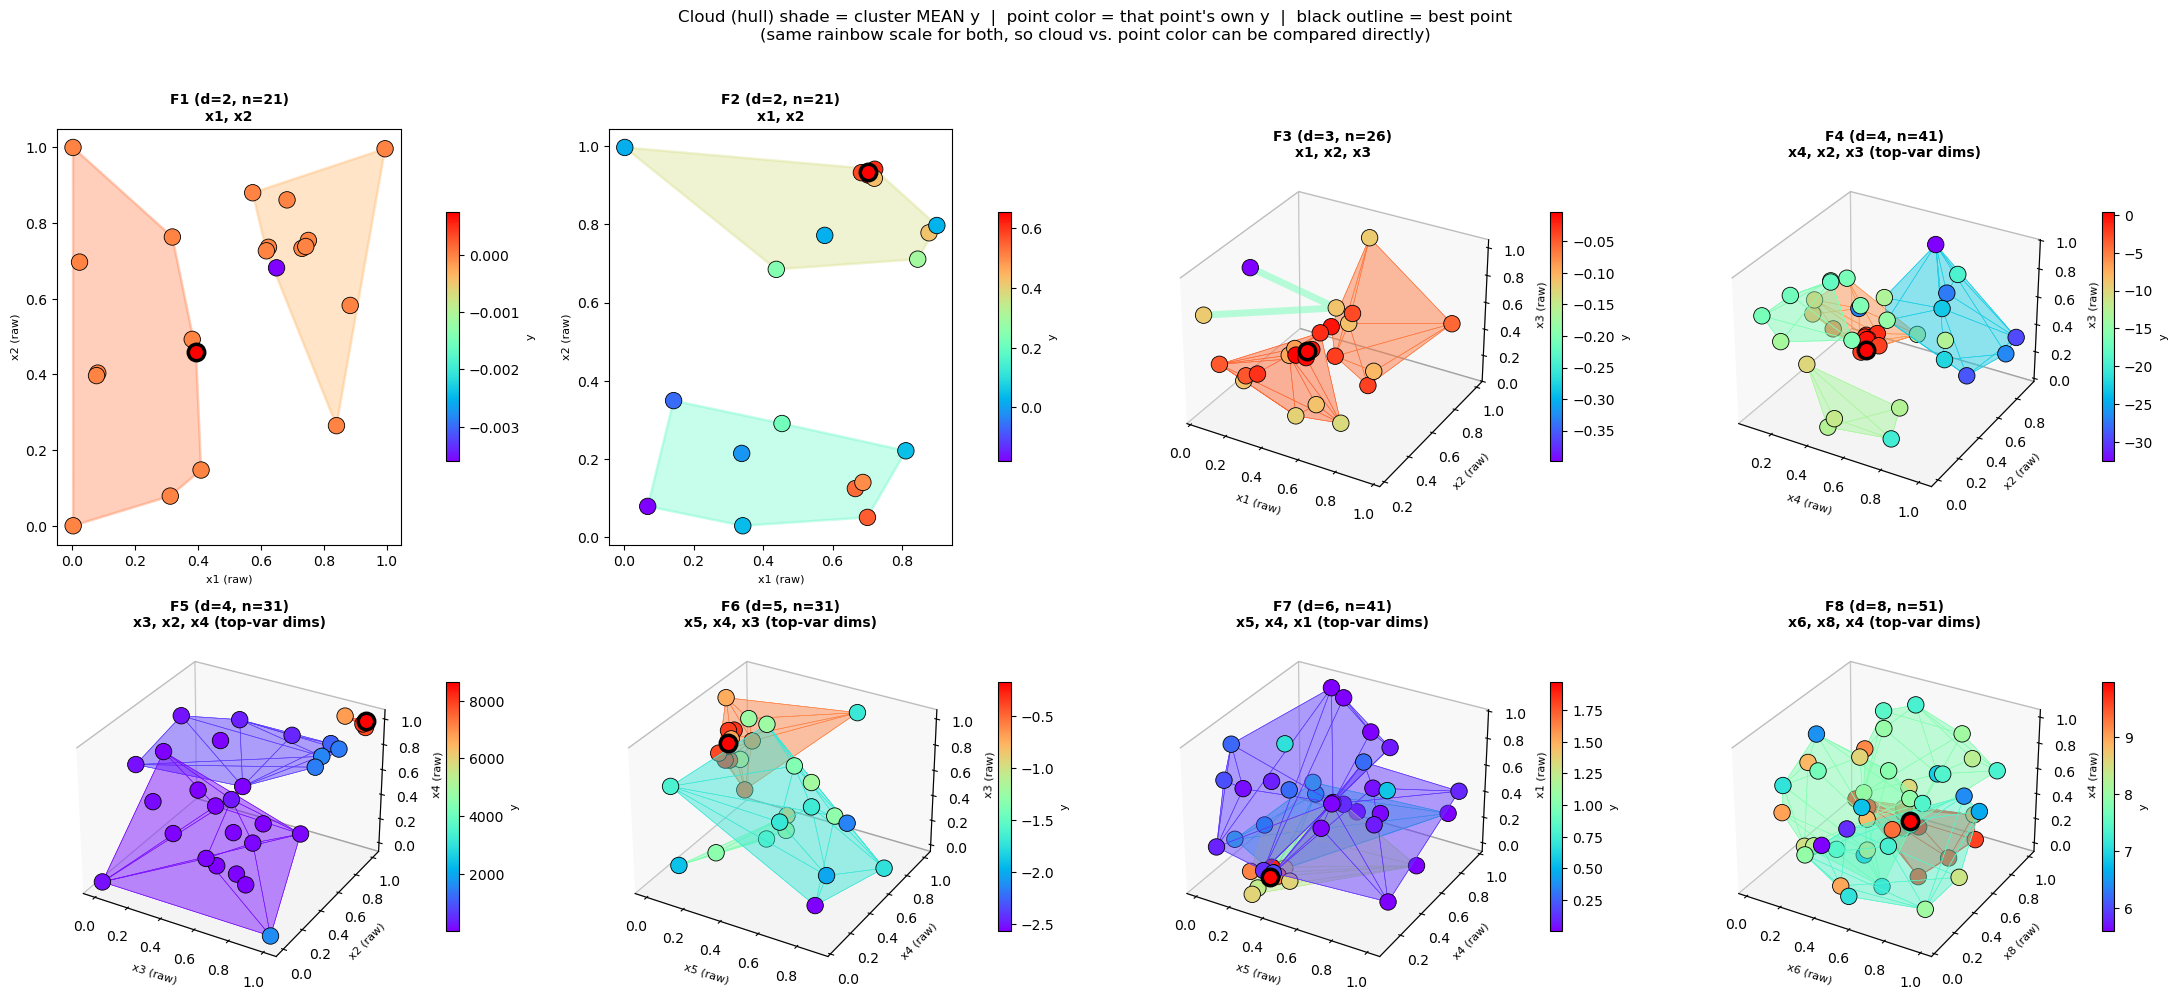

In [19]:
"""
Plot query-point clusters (k-means) per benchmark function as shaded
"cloud" regions (2D convex-hull polygons / 3D convex-hull polyhedra),
where:

    - cloud shade   = MEAN objective value y of all points in that cluster
    - point color   = that individual point's own y
    - black outline = best point found so far (drawn frontmost, even in 3D)

Clustering itself is unsupervised: k-means only ever sees X (the query
locations), standardized to zero mean / unit variance so all dimensions
contribute equally regardless of their raw scale. y is layered on
afterwards, purely for interpretation. Axes are plotted in RAW (original)
units, not standardized z-scores -- only the clustering step uses the
standardized version internally.

Functions with d == 2 are plotted as plain 2D scatter/hulls.
Functions with d == 3 use all 3 dims directly in 3D.
Functions with d > 3 use the 3 highest-variance dimensions (no PCA).

If a cluster's points are (numerically) coplanar / collinear, a proper
convex hull can't be formed (Qhull raises QhullError). In that case we
first retry with the 'QJ' (joggle) option, which perturbs points
slightly to force full-dimensionality; if that still fails, we fall
back to drawing a connecting line/curve through the points instead of
fabricating a volume/polygon.

This version takes X/y directly from memory (e.g. the all_X / all_y
lists of DataFrames/Series already loaded earlier in the notebook)
instead of reading .npy files from disk.

Usage (from a notebook / script that already has all_X, all_y defined):
    plot_clusters(all_X, all_y, out_path="clusters.png")
"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull, QhullError
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def force_front(collection):
    """Monkey-patch a 3D scatter collection so mplot3d's depth-sort
    always treats it as nearest-to-camera (drawn last / on top),
    regardless of its actual computed depth. mplot3d recomputes draw
    order every frame from do_3d_projection() and ignores a manually
    set zorder for that decision, so this is the standard workaround."""
    orig_proj = collection.do_3d_projection

    def patched():
        orig_proj()
        return -1e9  # smaller = closer to camera = drawn on top

    collection.do_3d_projection = patched


def safe_convex_hull(pts):
    """Try to build a ConvexHull, retrying with joggled input if the
    points are numerically degenerate (coplanar/collinear). Returns
    the ConvexHull object, or None if it truly can't be formed."""
    try:
        return ConvexHull(pts)
    except QhullError:
        try:
            return ConvexHull(pts, qhull_options="QJ")
        except QhullError:
            return None


def plot_clusters(all_X, all_y, out_path: str = "clusters.png", k_max: int = 4):
    """
    all_X : list of pandas DataFrames (or array-likes), one per function,
            each shaped (n, d) with columns x1..xd.
    all_y : list of pandas Series (or array-likes), one per function,
            each shaped (n,).
    """
    n_funcs = len(all_X)
    if n_funcs == 0:
        raise ValueError("all_X is empty -- nothing to plot")

    n_cols = min(4, n_funcs)
    n_rows = -(-n_funcs // n_cols)  # ceil

    cmap = plt.cm.rainbow
    fig = plt.figure(figsize=(5.5 * n_cols, 5 * n_rows))

    for i in range(n_funcs):
        fn_num = i + 1
        X = np.asarray(all_X[i])
        Y = np.asarray(all_y[i]).ravel()
        n, d = X.shape

        # Standardize so every dimension contributes equally to clustering/plotting
        Xs = StandardScaler().fit_transform(X)

        # Choose k: at least 2, at most k_max, roughly one cluster per ~8 points
        k = max(2, min(k_max, n // 8))
        labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)

        ymin, ymax = Y.min(), Y.max()
        norm = plt.Normalize(vmin=ymin, vmax=ymax)

        is_2d = d == 2
        if is_2d:
            dim_idx = [0, 1]
            ax = fig.add_subplot(n_rows, n_cols, i + 1)
        elif d == 3:
            dim_idx = [0, 1, 2]
            ax = fig.add_subplot(n_rows, n_cols, i + 1, projection="3d")
        else:
            # No PCA: just take the 3 highest-variance raw dimensions
            var = Xs.var(axis=0)
            dim_idx = list(np.argsort(var)[::-1][:3])
            ax = fig.add_subplot(n_rows, n_cols, i + 1, projection="3d")

        if not is_2d:
            ax.xaxis.pane.set_facecolor((0.95, 0.95, 0.95, 1.0))
            ax.yaxis.pane.set_facecolor((0.95, 0.95, 0.95, 1.0))
            ax.zaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1.0))
            ax.xaxis.pane.set_edgecolor("gray")
            ax.yaxis.pane.set_edgecolor("gray")
            ax.zaxis.pane.set_edgecolor("gray")
            ax.grid(False)

        # Plot in RAW (original) units -- clustering above used the
        # standardized Xs, but standardized z-scores are unintuitive to
        # read off an axis, so we draw with the real X values instead.
        X0 = X[:, dim_idx[0]]
        Y0 = X[:, dim_idx[1]]
        Z0 = X[:, dim_idx[2]] if not is_2d else None

        best_idx = np.argmax(Y)

        # ---- cloudy cluster regions, shaded by CLUSTER MEAN y ----
        for c in range(k):
            mask = labels == c
            cluster_mean_y = Y[mask].mean()
            color = cmap(norm(cluster_mean_y))

            if is_2d:
                pts = np.column_stack([X0[mask], Y0[mask]])
                if mask.sum() >= 3:
                    hull = safe_convex_hull(pts)
                    if hull is not None:
                        poly = Polygon(
                            pts[hull.vertices], closed=True,
                            facecolor=color, alpha=0.35,
                            edgecolor=color, linewidth=1.8, zorder=1,
                        )
                        ax.add_patch(poly)
                    else:
                        # degenerate (collinear) even after joggling -- draw a line
                        ax.plot(pts[:, 0], pts[:, 1], color=color, alpha=0.5,
                                lw=6, zorder=1)
                elif mask.sum() == 2:
                    ax.plot(pts[:, 0], pts[:, 1], color=color, alpha=0.5,
                            lw=6, zorder=1)
                # a single-point cluster gets no cloud -- nothing to enclose
            else:
                pts = np.column_stack([X0[mask], Y0[mask], Z0[mask]])
                if mask.sum() >= 4:
                    hull = safe_convex_hull(pts)
                    if hull is not None:
                        faces = [pts[simplex] for simplex in hull.simplices]
                        poly3d = Poly3DCollection(
                            faces, facecolor=color, edgecolor=color,
                            alpha=0.28, linewidths=0.4,
                        )
                        ax.add_collection3d(poly3d)
                    else:
                        # degenerate (coplanar/collinear) even after joggling --
                        # fall back to a connecting line rather than fabricating
                        # a volume from a flat point set
                        ax.plot(pts[:, 0], pts[:, 1], pts[:, 2],
                                color=color, alpha=0.5, lw=5)
                elif mask.sum() >= 2:
                    # not enough points for a volume -- draw a connecting line
                    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2],
                            color=color, alpha=0.5, lw=5)

        # ---- points, each colored by ITS OWN y ----
        for c in range(k):
            mask = labels == c
            idxs = np.where(mask)[0]
            rest = idxs[idxs != best_idx]
            if len(rest) == 0:
                continue
            common_kwargs = dict(cmap="rainbow", edgecolors="k",
                                  vmin=ymin, vmax=ymax)
            if is_2d:
                sc = ax.scatter(X0[rest], Y0[rest], s=140, c=Y[rest],
                                 marker="o", linewidths=0.6, alpha=1.0,
                                 zorder=3, **common_kwargs)
            else:
                sc = ax.scatter(X0[rest], Y0[rest], Z0[rest], s=140, c=Y[rest],
                                 marker="o", linewidths=0.6, alpha=1.0,
                                 depthshade=False, zorder=3, **common_kwargs)

        # ---- best point: same size, bold black outline, forced frontmost ----
        common_kwargs = dict(cmap="rainbow", edgecolors="black",
                              vmin=ymin, vmax=ymax)
        if is_2d:
            ax.scatter(X0[best_idx], Y0[best_idx], s=140, c=[Y[best_idx]],
                       marker="o", linewidths=2.5, alpha=1.0, zorder=10,
                       **common_kwargs)
        else:
            sc_best = ax.scatter(X0[best_idx], Y0[best_idx], Z0[best_idx],
                                  s=140, c=[Y[best_idx]], marker="o",
                                  linewidths=2.5, alpha=1.0, depthshade=False,
                                  zorder=10, **common_kwargs)
            force_front(sc_best)

        dim_note = f"x{dim_idx[0]+1}, x{dim_idx[1]+1}" + (
            "" if is_2d else f", x{dim_idx[2]+1}"
        )
        hd_note = " (top-var dims)" if d > 3 else ""
        ax.set_title(f"F{fn_num} (d={d}, n={n})\n{dim_note}{hd_note}",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel(f"x{dim_idx[0]+1} (raw)", fontsize=8)
        ax.set_ylabel(f"x{dim_idx[1]+1} (raw)", fontsize=8)
        if not is_2d:
            ax.set_zlabel(f"x{dim_idx[2]+1} (raw)", fontsize=8)
        cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label("y", fontsize=8)

    fig.suptitle(
        "Cloud (hull) shade = cluster MEAN y  |  point color = that point's own y  |  "
        "black outline = best point\n(same rainbow scale for both, so cloud vs. "
        "point color can be compared directly)",
        fontsize=12, y=1.02,
    )
    fig.tight_layout()
    fig.savefig(out_path, dpi=140, bbox_inches="tight")
    print(f"Saved: {out_path}")


if __name__ == "__main__":
    # Example standalone usage: assumes all_X, all_y already exist in scope
    # (e.g. built earlier via load_function()/append_from_txt() as in the
    # notebook). Adjust as needed if running this file directly.
    plot_clusters(all_X, all_y, out_path="clusters.png")

## Pipeline
Kernel + trust gate, multi-method importance, acquisitions/strategies, and the config-driven `run_all`. Edit `CONFIG` to steer any function; leave `strategy='auto'` to let the LOO gate route it.

In [ ]:
# =====================================================================
#  BBO capstone pipeline  —  Week 12
#  Changes vs W10:
#    Q1  duplicate-safe LOO: identical/near-identical X rows are now held
#        out as ONE group, not as independent folds. Previously an exact
#        duplicate's twin sat in ITS OWN training fold, so the model could
#        just look the answer up -- this is what was inflating F5's (two
#        rows at the (1,1,1,1) vertex) and F2's (one duplicated pair)
#        raw-scale LOO R2. Singletons behave exactly as before.
#    Q2  robust LOO diagnostics ride alongside the primary R2 in df_cmp:
#          loo_r2_trim1     -- R2 recomputed with the single worst LOO
#                               GROUP dropped
#          loo_rho          -- Spearman rank correlation, raw y vs raw
#                               LOO prediction (scale-free, so it can't be
#                               blown up by warp-inversion amplification)
#          amp_at_worst_fold-- local |dy/dz| of the fitted warp AT the
#                               worst fold's prediction; >>1 means that
#                               fold's collapse is a tail-amplification
#                               artefact of the warp, not a bad GP fit
#          single_fold_driven -- True when the primary R2 fails the 0.30
#                               gate but r2_trim1 and rho both look fine,
#                               i.e. one point is doing all the damage
#          n_clipped         -- how many LOO folds hit warp_inv's P0
#                               pole-safety clip (Yeo-Johnson domain edge)
#          clip_dominated    -- True when the R2 collapse traces to MANY
#                               folds landing on that same clip, not a
#                               genuinely bad fit; predicted-vs-true plots
#                               show this as a flat "stagnant" band, since
#                               a stable per-fold lambda puts every clipped
#                               fold at almost the same raw value
#    Q3  route() is UNCHANGED on purpose. It still gates on the honest,
#        single-number raw R2 -- that's the conservative, correct default.
#        The Q2 columns are visibility, not an automatic override: whether
#        F3/F7's post-fix collapse is worth manually overriding to
#        "global" is a risk call with the evaluation budget left, and it's
#        made by reading single_fold_driven, not silently decided by the
#        pipeline.
#    Q4  fixed a real scale-mismatch bug in the P0 clip itself: the pole
#        -1/lambda is derived in RAW Yeo-Johnson units, but PowerTransformer
#        standardizes its own output by default and that's the space the GP
#        actually predicts in. The old clip compared raw-space vs
#        standardized-space directly, so it fired at ~50% of the true
#        domain boundary -- e.g. for F7 it was truncating GP predictions
#        roughly twice as early as necessary. _yeo_std_pole converts the
#        pole into the correct (standardized) coordinate before comparing.
#    Q5  F7: warp switched yeo -> log (CONFIG[7], not a pipeline change).
#        Post-Q4-fix, yeo's per-fold lambda for F7 still sits near a real
#        domain pole and one LOO fold genuinely blows up on inversion (raw
#        R2 -0.697). log has no such pole for F7 (all y>0, no offset
#        needed): R2 +0.871, R2_trim1 +0.894. Checked yeo/log/None against
#        real data before switching -- not a guess.
#    Q6  F3: strategy manually overridden auto -> global (CONFIG[3]).
#        Auto-route said turbo (raw R2=0.280 < 0.30 gate), but that's
#        single-fold-driven -- trim1=0.561, rho=0.858 once the one hard
#        extrapolation point is set aside. Track record backed the switch:
#        only 3 of the last 11 rounds improved on the incumbent under
#        turbo. Config comment on CONFIG[3] has the full reasoning.
#    Q7  fixed predicted_y reporting for "needle": it always re-predicted
#        with the GLOBAL gp, but needle SELECTS its candidate with a LOCAL
#        gp fit on ~12 nearby points at a much tighter lengthscale -- the
#        global model has no local resolution there and reported nonsense
#        (F4: -0.48 against a 0.44 incumbent). suggest_needle now returns
#        its local gp as the row's 3rd element; run_all reports with
#        whichever model actually picked the point. Every other strategy's
#        3rd element is still None, so this is a no-op everywhere else.
#        x_next is UNCHANGED -- selection never used the global gp here,
#        only the number displayed alongside it was wrong.
#  Changes vs W9 (unchanged, kept for reference):
#    P0  NaN-safe warp_inv / loo_cv / route   (F7 was routed by a NaN)
#    P1  ARD saturation read as MULTIMODAL, not irrelevant (LS_UPPER 1e4 -> 20)
#    P2  multi-basin TuRBO round-robin                     (F2)
#    P3  local-GP needle refinement                        (F4)
#    P4  basin separation measured in ARD lengthscale units, not raw input
#        units. In raw space an offset in a near-irrelevant dimension
#        dominates the distance and fakes a basin the GP cannot see.
#    P5  corner strategy for F5 (vertex optimum, deterministic, free budget)
#    P6  config is a plain dict again; SimpleNamespace only at read time
#
#  Changes vs W11 (this edit):
#    D1  run_all() no longer reads .npy files from disk. It now takes
#        all_X / all_y directly (lists of DataFrames/Series, one per
#        function, already in memory -- e.g. built earlier from the
#        original initial_data_NN/.npy loader PLUS whatever was appended
#        from inputs.txt/outputs.txt). load_function()/DATA_DIR are no
#        longer used by the pipeline; load_function() is kept only as a
#        convenience if you ever want to rebuild all_X/all_y from disk
#        yourself before calling run_all().
#
#  Changes vs W12 (this edit):
#    E1  WEEK bumped 10 -> 11. The multi-basin round-robin index is
#        (week + basin_offset) % len(anchors); WEEK was never advanced
#        after the week-11 submission, so re-running this cell for week
#        12 as-is put F1/F2 straight back on the SAME anchor just used --
#        F1's last two real rounds (rows -2/-1) both already sit in that
#        basin, while F1's actual best y is still the OTHER anchor's
#        incumbent from 4 rounds back. Inferred from F1's own W11 comment
#        ("10 % 3 puts week 10 back on the incumbent" -- i.e. WEEK was
#        already 10 while planning week 11) plus matching the last real
#        submitted point against a WEEK=10 replay. Cross-check against
#        your own W11 run log before trusting this if you kept one.
#    E2  F4 (CONFIG[4]): shrink 0.012 -> 0.03. The W11 comment's own
#        decision rule ("~-0.4 back means real, ~-1.1 means a spike,
#        widen to ~0.03 if real") has now been triggered by the data --
#        the needle probe came back at +0.4364, decisively past the old
#        -0.2646 incumbent, not just "back near -0.4". Two rounds left;
#        a wider box around a confirmed-real region should out-earn
#        staying at the old, tighter shrink.
# =====================================================================
import numpy as np, pandas as pd, itertools
from types import SimpleNamespace
from scipy.stats import norm, qmc, spearmanr
from scipy.optimize import differential_evolution
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import PowerTransformer

RNG = np.random.default_rng(42)

def fn_rng(fn, week=None):
    """Per-function generator. Each function draws from its own stream, so a
    config change to one function cannot perturb another's suggestion."""
    return np.random.default_rng([42, int(fn), int(WEEK if week is None else week)])
EPS, UB, LS_UPPER = 1e-6, 1-1e-6, 20.0      # P1: was 1e4
WEEK = 11                                    # E1: bumped from 10, drives multi-basin round-robin

# ------------------------- SPEED KNOBS -------------------------
# Defaults below are the FAST path, for iterating on plots/config.
# Before quoting numbers in the report, set REPORT_MODE = True.
REPORT_MODE   = True
REFIT_HYPERS  = REPORT_MODE   # refit GP hypers on every LOO fold (~12x slower)
COMPARE_LOO   = REPORT_MODE   # also compute the old warped-scale BEFORE column
PERM_REPEATS  = 30 if REPORT_MODE else 10
RF_TREES      = 300 if REPORT_MODE else 150
GP_RESTARTS   = None          # None -> max(5, 2*d);  int -> fixed
# ---------------------------------------------------------------


def load_function(fn):
    """Kept only as an optional convenience for rebuilding all_X/all_y from
    disk yourself (e.g. `all_X=[load_function(f)[0] for f in range(1,9)]`).
    run_all() no longer calls this -- see D1."""
    X = np.load(f"{DATA_DIR}/function_{fn}/initial_inputs.npy")
    Y = np.load(f"{DATA_DIR}/function_{fn}/initial_outputs.npy").ravel()
    cols = [f"x{i+1}" for i in range(X.shape[1])]
    return pd.DataFrame(X, columns=cols), pd.Series(Y, name="y")


# =====================================================================
#  CONFIG  —  plain dicts. Anything you omit falls back to DEFAULTS.
# =====================================================================
DEFAULTS = dict(
    strategy      = "auto",   # auto | global | turbo | turbo_mb | needle | explore | corners
    warp          = None,     # None | "log" | "yeo"
    ls_floor      = 0.05,     # Matern lengthscale lower bound
    noise         = True,     # add WhiteKernel
    freeze        = True,     # allow dims to be frozen at all
    n_candidates  = 4000,
    nu            = 2.5,      # Matern smoothness
    override_frozen = (),     # 0-BASED dim indices forced frozen, e.g. (0, 2) = x1, x3
    # --- P2 multi-basin ---
    min_sep       = 1.0,      # ARD LENGTHSCALE UNITS since P4 (was raw, 0.25)
    basin_rank    = "y",      # "y" (signed) | "abs" (envelope)
    max_basins    = 3,
    basin_offset  = 0,        # shifts which anchor this WEEK lands on
    turbo_ti      = 0.4,      # initial trust-region length
    # --- P3 needle ---
    radius        = 0.20,     # local-GP data radius
    shrink        = 0.06,     # half-width of the needle box
    xi            = 0.001,    # EI exploration margin
)


CONFIG = {

    # -----------------------------------------------------------------
    # F1  2D  |  best 7.504e-4 @ (0.3945, 0.4594)
    # Oscillatory, outputs span 245 decades, GP unusable (LOO R2 -0.11).
    # The largest |y| anywhere is -3.6e-3 @ (0.650, 0.682) -- 4.8x the
    # incumbent and NEGATIVE. rank="abs" anchors the envelope there.
    # max_basins=2 is load-bearing: at 3 anchors, 10 % 3 = 1 puts week 10
    # back on the incumbent instead of the lobe.
    # -----------------------------------------------------------------
    1: dict(strategy="turbo_mb", warp=None, nu=1.5,
            basin_rank="abs", min_sep=1.0, turbo_ti=0.09, max_basins=2),

    # -----------------------------------------------------------------
    # F2  2D  |  best 0.6548 @ (0.7026, 0.9353)   STOCHASTIC
    # sigma_hat in [0.04, 0.09] -- the banked best is ~0.9 sigma of
    # winner's curse above its local mean. ls = (0.077, 4.07), so x2 is
    # ~53x less relevant than x1. The r9 "0.80 basin jump" was 0.28
    # lengthscales: 99.8% of the raw distance sat in x2. Under P4 the
    # second anchor becomes (0.878, 0.779) -- the rising unsampled edge
    # at x1 > 0.88. basin_offset=1 takes that edge THIS week; with four
    # evaluations left, information is worth more early than late.
    # -----------------------------------------------------------------
    2: dict(strategy="turbo_mb", nu=2.5,
            min_sep=1.0, max_basins=2, basin_offset=1),

    # -----------------------------------------------------------------
    # F3  3D  |  best -0.00433
    # LOO R2 0.240, just under the 0.30 gate -- expect it to flip to
    # "global" under REPORT_MODE=True. Little headroom left if this
    # family is bounded above by 0.
    # Q6: manually overridden to "global" for week 11. Auto-route says
    # turbo (raw R2=0.280 < 0.30 gate), but that's single-fold-driven --
    # trim1=0.561, rho=0.858 once the one hard extrapolation point is set
    # aside. Track record backs the switch too: only 3 of the last 11
    # rounds improved on the incumbent under turbo. If the "bounded by 0"
    # read is right there's little upside left either way, but global is
    # a genuinely different search pattern where turbo has plateaued.
    # -----------------------------------------------------------------
    3: dict(strategy="global", warp="yeo", nu=1.5),

    # -----------------------------------------------------------------
    # F4  4D  |  best 0.4364 @ (0.4101, 0.4202, 0.3510, 0.4401)
    # E2: shrink 0.012 -> 0.03 -- this was the W11 comment's own widen
    # trigger. The short probe came back real and then some: old
    # incumbent was -0.2646, the probe found +0.4364 (a +0.70 jump), well
    # past the "~-0.4 back" bar that would merely have confirmed it. Two
    # rounds left; widen the box around a region that's proven itself.
    # -----------------------------------------------------------------
    4: dict(strategy="needle", warp="yeo", nu=1.5,
            shrink=0.03, radius=0.10, xi=0.0),

    # -----------------------------------------------------------------
    # F5  4D  |  best 8662.405 @ (1, 1, 1, 1)
    # Deterministic (exact replicate at the vertex) and the vertex beats
    # every interior point by ~5.6x. Nothing interior can win, so the
    # four remaining evaluations are free. Spend them on vertices.
    # -----------------------------------------------------------------
    5: dict(strategy="corners", warp="yeo", nu=2.5),

    # -----------------------------------------------------------------
    # F6  5D  |  best -0.1692
    # The only well-conditioned GP: ls all in [0.73, 1.40], noise 0.018,
    # LOO R2 0.871. Straight EI. No cleverness required.
    # -----------------------------------------------------------------
    6: dict(warp="yeo", nu=1.5),

    # -----------------------------------------------------------------
    # F7  6D  |  best 1.9122 @ (0, 0.0817, 0, 0.2976, 0.2684, 0.7335)
    # x1 and x3 are exactly 0 at the incumbent; x3 is saturated at ls=20
    # with noise ~0, so multimodal_flag is False and guard_freeze will
    # not undo the override. Freezing both pins the search to the 4D
    # face where the optimum actually lives.
    # Q5: warp switched yeo -> log. All y>0 here so log needs no offset.
    # Post-Q4-fix, yeo's per-fold lambda sits near a domain pole and one
    # LOO fold genuinely blows up to y=6.29 on inversion (true max is
    # 1.91) -- raw R2 -0.697. log has no such pole: R2 +0.871, R2_trim1
    # +0.894. Checked all three warp choices against real data before
    # switching (see chat) -- this isn't a guess.
    # -----------------------------------------------------------------
    7: dict(warp="log", nu=1.5, override_frozen=(0, 2)),

    # -----------------------------------------------------------------
    # F8  8D  |  best 9.9720
    # Converged: 9.9720 / 9.9663 / 9.9620 over the last three rounds is
    # plateau noise. Nothing left to protect, so take the risk here
    # rather than on a function with a live gradient. Back to "auto"
    # for week 13.
    # -----------------------------------------------------------------
    8: dict(strategy="explore", warp="yeo", nu=2.5),
}


def get_cfg(fn):
    """Merge a function's overrides onto DEFAULTS and return attribute-access.

    Dict in, cfg.foo out -- so the config stays a plain literal you can edit
    weekly, while every cfg.<field> reference downstream is unchanged. The
    unknown-key check is the one thing the dataclass gave us that a bare dict
    does not: without it, a typo like min_seq=1.0 silently does nothing.
    """
    over = CONFIG.get(fn, {})
    bad = set(over) - set(DEFAULTS)
    if bad:
        raise KeyError(f"F{fn}: unknown config key(s) {sorted(bad)} — check spelling")
    return SimpleNamespace(**{**DEFAULTS, **over})


def show_config(fns=range(1, 9)):
    """One row per function, defaults included, so what actually ran is legible."""
    return pd.DataFrame([vars(get_cfg(f)) for f in fns],
                        index=pd.Index(list(fns), name="function"))


def build_kernel(nd, cfg):
    k = Matern(np.ones(nd), (cfg.ls_floor, LS_UPPER), nu=cfg.nu)
    return k + WhiteKernel(1e-3, (1e-6, 1.0)) if cfg.noise else k


def make_gp(X, Y, cfg):
    gp = GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
        alpha=1e-10 if cfg.noise else 1e-6,
        n_restarts_optimizer=GP_RESTARTS or max(5, 2*X.shape[1]),
        normalize_y=True, random_state=42)
    return gp.fit(X, Y)


# ---------- warp: fit on a slice, apply, invert (array-safe) ----------
def fit_warp(Ytr, w):
    if w == "log":
        s = 0.0 if Ytr.min() > 0 else 1 - Ytr.min(); return ("log", s)
    if w == "yeo":
        return ("yeo", PowerTransformer("yeo-johnson").fit(Ytr.reshape(-1, 1)))
    return (None, None)


def warp_apply(Y, m):
    k, o = m
    if k == "log": return np.log(Y + o)
    if k == "yeo": return o.transform(Y.reshape(-1, 1)).ravel()
    return Y


def warp_inv(y, m):
    """P0: Yeo-Johnson with lambda<0 has a pole at z=-1/lambda. A GP prediction
    past it returns NaN, which poisons LOO R2 and silently reroutes.
    Q4: the pole is now expressed in the standardized z-space the GP
    actually predicts in (see _yeo_std_pole) -- the original comparison
    mixed raw-space and standardized-space and clipped far too early."""
    k, o = m
    y = np.atleast_1d(np.asarray(y, float))
    if k == "log":
        return np.exp(np.clip(y, -700, 700)) - o
    if k == "yeo":
        lam = float(o.lambdas_[0])
        pole = _yeo_std_pole(o, lam)
        if pole is not None:
            if lam < 0:
                y = np.minimum(y, pole - 1e-8)
            elif lam > 2:
                y = np.maximum(y, pole + 1e-8)
        out = o.inverse_transform(y.reshape(-1, 1)).ravel()
        if not np.isfinite(out).all():
            fill = np.nanmin(out[np.isfinite(out)]) if np.isfinite(out).any() else 0.0
            out = np.nan_to_num(out, nan=fill, posinf=fill, neginf=fill)
        return out
    return y


def warp_fwd(Y, w):
    m = fit_warp(Y, w); return warp_apply(Y, m), m


def _yeo_std_pole(o, lam):
    """Q4 fix: the Yeo-Johnson domain pole (-1/lambda for lambda<0, or
    1/(2-lambda) for lambda>2), converted into the STANDARDIZED z-space the
    GP actually predicts in. PowerTransformer(standardize=True) -- the
    sklearn default -- z-scores its own Yeo-Johnson output before the GP
    ever sees it, but the P0 patch computed the pole in RAW Yeo-Johnson
    units and compared it directly against the (standardized) GP output.
    For F7 that fired the safety clip at ~51% of the way to the true
    boundary -- every fold whose z-prediction was even moderately extreme
    got truncated to nearly the same raw value, which is what showed up as
    a flat 'stagnant' band on the predicted-vs-true plot. Falls back to
    the raw-space pole (the original P0 behaviour) if the internal scaler
    isn't found, so this degrades safely across sklearn versions."""
    try:
        mean_, scale_ = float(o._scaler.mean_[0]), float(o._scaler.scale_[0])
    except Exception:
        mean_, scale_ = 0.0, 1.0
    if lam < 0:
        return ((-1.0 / lam) - mean_) / scale_
    if lam > 2:
        return ((1.0 / (2.0 - lam)) - mean_) / scale_
    return None


def matern_ls(gp):
    k = gp.kernel_
    return np.atleast_1d(k.k1.length_scale if hasattr(k, "k1") else k.length_scale)


# ---------- Q1: group identical/near-identical rows for LOO ----------
def _loo_groups(X, decimals=9):
    """Group id per row. Rows that agree to `decimals` places share a group,
    so leave-one-out holds the WHOLE group out together. Without this, an
    exact-duplicate observation sits in the training fold for its own
    twin's held-out point and the model gets to look the answer up -- this
    is what inflated F5's LOO R2 (two rows at the (1,1,1,1) vertex, y
    identical to machine precision) and, more mildly, F2's (one duplicated
    pair). A row with no duplicate is its own singleton group and behaves
    exactly like ordinary LOO."""
    _, inv = np.unique(np.round(X, decimals), axis=0, return_inverse=True)
    return inv.ravel()


def _warp_local_slope(m, z0, h=1e-3):
    """|dy/dz| at z0, via central finite difference on the fitted warp.
    This is the number that explains why a Yeo-Johnson-warped LOO R2 can
    collapse on raw scale: the transform stabilises variance for the BULK
    of the distribution but its inverse gets steep in the tail it
    compressed, so a residual that looks small and well-behaved in z-space
    can be many times larger once inverted back to raw y -- and it lands
    hardest exactly on extreme points like an incumbent best."""
    k, _ = m
    if k is None:
        return 1.0
    y_plus = warp_inv(z0 + h, m)[0]
    y_minus = warp_inv(z0 - h, m)[0]
    return abs(float(y_plus - y_minus) / (2 * h))


def _r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2) + 1e-12
    return 1 - ss_res / ss_tot


def _warp_clipped(pw, m):
    """Whether warp_inv's P0 safety clip triggers for this warped-space
    prediction -- i.e. whether the GP's z-space output fell past the
    Yeo-Johnson domain pole (in the Q4-corrected, standardized coordinate
    -- see _yeo_std_pole) and got truncated to the boundary instead of
    genuinely inverted. A clipped fold's raw-scale residual reflects where
    the clip lands, not what the GP actually predicted."""
    k, o = m
    pw = np.atleast_1d(pw)
    if k != "yeo":
        return np.zeros(len(pw), dtype=bool)
    lam = float(o.lambdas_[0])
    pole = _yeo_std_pole(o, lam)
    if pole is None:
        return np.zeros(len(pw), dtype=bool)
    if lam < 0:
        return pw >= pole - 1e-8
    if lam > 2:
        return pw <= pole + 1e-8
    return np.zeros(len(pw), dtype=bool)


def _robust_loo_diag(Yraw, p_raw, groups, ok, amp, clip, r2_gate=0.30, rho_gate=0.70):
    """Q2/Q3: companion metrics that disambiguate 'GP genuinely unreliable'
    from 'one hard-to-extrapolate point is dominating a fragile R2' from
    'the pole-clip is flattening several folds to the same value' --
    relevant with n in the 20s-40s and heavily skewed y, where a single
    held-out residual can dominate both SS_res and SS_tot."""
    yt, yp = Yraw[ok], p_raw[ok]
    r2 = _r2(yt, yp)

    sq_err = np.where(ok, (Yraw - p_raw) ** 2, -np.inf)
    grp_ids = np.unique(groups[ok])
    grp_err = {g: sq_err[(groups == g) & ok].sum() for g in grp_ids}
    worst_g, r2_trim1, amp_worst = None, np.nan, np.nan
    if len(grp_ids) > 1:
        worst_g = max(grp_err, key=grp_err.get)
        keep = ok & (groups != worst_g)
        if keep.sum() >= 3:
            r2_trim1 = _r2(Yraw[keep], p_raw[keep])
        amp_worst = float(np.nanmean(amp[groups == worst_g]))

    rho = float(spearmanr(yt, yp).correlation) if len(yt) >= 3 else np.nan
    single_fold_driven = bool(
        r2 < r2_gate and np.isfinite(r2_trim1) and r2_trim1 >= r2_gate
        and np.isfinite(rho) and rho >= rho_gate
    )
    n_clipped = int(clip[ok].sum())
    clip_dominated = bool(
        r2 < r2_gate and n_clipped >= 2 and np.isfinite(rho) and rho >= rho_gate
    )
    return {"r2": r2, "r2_trim1": r2_trim1, "rho": rho, "worst_group": worst_g,
            "amp_at_worst_fold": amp_worst, "n_groups": int(len(np.unique(groups))),
            "n_points": int(len(groups)), "single_fold_driven": single_fold_driven,
            "n_clipped": n_clipped, "clip_dominated": clip_dominated}


# ---------- LOO CV: raw-scale score, per-fold warp, NaN-safe, dup-safe ----------
def loo_cv(X, Yraw, cfg, refit_hypers=None):
    """Raw-scale LOO R2, per-fold warp, NaN-safe, duplicate-safe (Q1),
    pole-clip aware (Q3).

    refit_hypers=False (the fast default) tunes the kernel ONCE on the full
    data and reuses it for every fold via optimizer=None -- ~12x faster.
    This is mildly optimistic: the shared hyperparameters have seen the
    held-out point. Use REPORT_MODE=True for the numbers you actually quote.

    Returns (p_raw, r2, diag) -- diag carries the Q2/Q3 robust companions.
    """
    if refit_hypers is None:
        refit_hypers = REFIT_HYPERS

    ktuned = None
    if not refit_hypers:
        m0 = fit_warp(Yraw, cfg.warp)
        ktuned = GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
            alpha=1e-10 if cfg.noise else 1e-6, n_restarts_optimizer=3,
            normalize_y=True, random_state=42).fit(X, warp_apply(Yraw, m0)).kernel_

    groups = _loo_groups(X)                          # Q1
    p_raw = np.full(len(Yraw), np.nan)
    amp = np.full(len(Yraw), np.nan)
    clip = np.zeros(len(Yraw), dtype=bool)            # Q3
    for gid in np.unique(groups):
        te = np.where(groups == gid)[0]
        tr = np.where(groups != gid)[0]
        m = fit_warp(Yraw[tr], cfg.warp)          # warp still refits per fold
        g = (GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
                 alpha=1e-10 if cfg.noise else 1e-6,
                 n_restarts_optimizer=3, normalize_y=True, random_state=42)
             if refit_hypers else
             GaussianProcessRegressor(ktuned, optimizer=None,
                 alpha=1e-10 if cfg.noise else 1e-6, normalize_y=True,
                 random_state=42))
        g.fit(X[tr], warp_apply(Yraw[tr], m))
        pw = np.atleast_1d(g.predict(X[te]))
        p_raw[te] = warp_inv(pw, m) if cfg.warp else pw
        amp[te] = [_warp_local_slope(m, z) for z in pw] if cfg.warp else 1.0
        clip[te] = _warp_clipped(pw, m) if cfg.warp else False

    ok = np.isfinite(p_raw)
    if ok.sum() < 3:
        diag = {"r2": -np.inf, "r2_trim1": np.nan, "rho": np.nan, "worst_group": None,
                "amp_at_worst_fold": np.nan, "n_groups": int(len(np.unique(groups))),
                "n_points": int(len(groups)), "single_fold_driven": False,
                "n_clipped": int(clip.sum()), "clip_dominated": False}
        return p_raw, -np.inf, diag
    if ok.sum() < len(Yraw):
        print(f"    [loo_cv] dropped {(~ok).sum()}/{len(Yraw)} non-finite folds")
    diag = _robust_loo_diag(Yraw, p_raw, groups, ok, amp, clip)
    return p_raw, diag["r2"], diag


def loo_cv_warped(X, Yw, cfg):
    """Original behaviour, kept ONLY to populate the BEFORE column."""
    p = np.zeros(len(Yw))
    for tr, te in LeaveOneOut().split(X):
        g = GaussianProcessRegressor(build_kernel(X.shape[1], cfg),
            alpha=1e-10 if cfg.noise else 1e-6, n_restarts_optimizer=3,
            normalize_y=True, random_state=42).fit(X[tr], Yw[tr])
        p[te] = g.predict(X[te])
    r2 = 1 - np.sum((Yw-p)**2) / (np.sum((Yw-Yw.mean())**2) + 1e-12)
    return p, r2


def _n01(v):
    v = np.clip(np.asarray(v, float), 0, None); return v/v.max() if v.max() > 0 else v


def gp_grad_sens(gp, nd, ns=512, h=1e-3):
    Xs = np.clip(qmc.Sobol(d=nd, seed=42).random(ns), EPS, UB)
    base = gp.predict(Xs); g = np.zeros(nd)
    for j in range(nd):
        Xp = Xs.copy(); Xp[:, j] = np.clip(Xp[:, j]+h, EPS, UB)
        g[j] = np.sqrt(np.mean(((gp.predict(Xp)-base)/h)**2))
    return g


# ---------- P1: saturation = multimodality, not irrelevance ----------
def diagnose_saturation(gp, noise_thresh=0.02):
    """A stationary Matern cannot represent two separated basins in one dim.
    Its least-bad fit is ls -> upper bound (flatten it) with the mode-to-mode
    variance dumped into WhiteKernel. Both symptoms together = multimodal."""
    k = gp.kernel_
    ls = np.atleast_1d(k.k1.length_scale if hasattr(k, "k1") else k.length_scale)
    noise = k.k2.noise_level if hasattr(k, "k2") else 0.0
    saturated = ls >= 0.5 * LS_UPPER
    return {"lengthscales": ls, "noise": float(noise),
            "saturated_dims": np.where(saturated)[0],
            "multimodal_flag": bool(saturated.any() and noise > noise_thresh)}


def guard_freeze(frozen, sat):
    """Never freeze a dimension flagged as multimodal."""
    frozen = np.asarray(frozen).copy()
    if sat["multimodal_flag"]:
        frozen[sat["saturated_dims"]] = False
    return frozen


def dimension_importance(X, Y, gp, cfg):
    nd = X.shape[1]; ls = matern_ls(gp)
    ard = _n01(1/np.clip(ls, 1e-6, None)); grad = _n01(gp_grad_sens(gp, nd))
    rf = RandomForestRegressor(RF_TREES, random_state=42, n_jobs=-1).fit(X, Y)
    perm = _n01(permutation_importance(rf, X, Y, n_repeats=PERM_REPEATS,
                                       random_state=42, n_jobs=-1).importances_mean)
    try:
        import shap
        sv = shap.TreeExplainer(rf).shap_values(X, check_additivity=False)
        shp = _n01(np.abs(sv).mean(0))
    except Exception:
        shp = np.full(nd, np.nan)
    gp_fam = np.nanmean(np.vstack([ard, grad]), 0)
    rf_fam = np.nanmean(np.vstack([perm, shp]), 0)
    cons = np.nanmean(np.vstack([gp_fam, rf_fam]), 0)
    disagree = np.abs(gp_fam - rf_fam)

    sat = diagnose_saturation(gp)
    saturated = ls >= 0.5*LS_UPPER
    frozen = saturated & (gp_fam < 0.15) & (rf_fam < 0.15)
    for j in cfg.override_frozen: frozen[j] = True
    if not cfg.freeze: frozen[:] = False
    frozen = guard_freeze(frozen, sat)                      # P1

    return pd.DataFrame({"dim":[f"x{j+1}" for j in range(nd)], "ard":np.round(ard,3),
        "gp_grad":np.round(grad,3), "rf_perm":np.round(perm,3), "shap":np.round(shp,3),
        "gp_fam":np.round(gp_fam,3), "rf_fam":np.round(rf_fam,3),
        "consensus":np.round(cons,3), "disagree":np.round(disagree,3),
        "lengthscale":np.round(ls,2), "saturated":saturated, "frozen":frozen})


def aEI(m,s,ym,ys,xi=0.01):
    x=xi*max(ys,1e-6); z=(m-ym-x)/(s+1e-9)
    e=(m-ym-x)*norm.cdf(z)+s*norm.pdf(z); e[s<1e-10]=0; return e
def aUCB(m,s,t,d):
    return m+min(np.sqrt(2*np.log(d*t**2*np.pi**2/3.0)),3.0)*s
def aPI(m,s,ym,ys,xi=0.01):
    x=xi*max(ys,1e-6); return norm.cdf((m-ym-x)/(s+1e-9))


def _opt_active(score, anchor, active, ps=20, mi=50):
    nd = len(anchor)
    if not active: return anchor.copy()
    def neg(x):
        x = np.atleast_2d(x)
        if x.shape[0] == len(active) and x.shape[1] != len(active): x = x.T
        full = np.tile(anchor, (x.shape[0], 1)); full[:, active] = x
        s = -np.atleast_1d(score(full)); return s if s.shape[0] > 1 else s[0]
    r = differential_evolution(neg, [(EPS,UB)]*len(active), vectorized=True,
        updating="deferred", popsize=ps, maxiter=mi, tol=1e-7, seed=42, polish=True)
    out = anchor.copy(); out[active] = np.clip(r.x, EPS, UB); return out


def suggest_global(X, Y, gp, imp, cfg):
    nd=X.shape[1]; ys=Y.std(); ym=Y.max(); xb=X[np.argmax(Y)]
    active=[j for j in range(nd) if not imp["frozen"].iloc[j]]
    def mk(n):
        def sc(f):
            m,s=gp.predict(f,return_std=True)
            return aEI(m,s,ym,ys) if n=="EI" else (aUCB(m,s,len(Y),max(len(active),1)) if n=="UCB" else aPI(m,s,ym,ys))
        return sc
    return [(n, _opt_active(mk(n), xb, active), None) for n in ("EI","UCB","PI")]


def suggest_explore(X, Y, gp, imp, cfg, rng=None):
    rng = RNG if rng is None else rng
    nd=X.shape[1]; xb=X[np.argmax(Y)]
    C = rng.uniform(EPS, UB, (cfg.n_candidates, nd))
    for j in range(nd):
        if imp["frozen"].iloc[j]: C[:,j]=xb[j]
    d=np.min(np.linalg.norm(C[:,None,:]-X[None,:,:],axis=2),axis=1)
    return [("MD", np.clip(C[np.argmax(d)],EPS,UB), None)], None


# ---------- P5: vertex lottery  (F5) ----------
def suggest_corners(fn, X, Y, cfg, rng=None):
    """F5's incumbent is a box vertex, reproduces exactly, and beats every
    interior point by ~5.6x. Nothing interior can win, so the remaining
    evaluations cannot lower the banked best. The only way 8662.405 falls is
    a second unseen spike -- and unseen means far from the data -- so take
    the vertex with the largest min-distance to the observed set."""
    nd = X.shape[1]
    V = np.array(list(itertools.product([EPS, UB], repeat=nd)))
    d = np.min(np.linalg.norm(V[:, None, :] - X[None, :, :], axis=2), axis=1)
    return [("corner", V[np.argmax(d)], None)], None


TURBO_STATE = {}
NEEDLE_STATE = {}


def suggest_turbo(fn, X, Y, gp, imp, cfg, ti=None, tmin=0.05, tmax=0.8, st_=3, ft=3,
                  rng=None):
    rng = RNG if rng is None else rng
    ti = cfg.turbo_ti if ti is None else ti
    tmin = min(tmin, ti)
    nd=X.shape[1]; ym=Y.max(); xb=X[np.argmax(Y)]
    s=TURBO_STATE.setdefault(fn,{"length":ti,"succ":0,"fail":0,"last":ym})
    if ym>s["last"]: s["succ"]+=1; s["fail"]=0
    else: s["fail"]+=1; s["succ"]=0
    if s["succ"]>=st_: s["length"]=min(tmax,s["length"]*2); s["succ"]=0
    elif s["fail"]>=ft: s["length"]=max(tmin,s["length"]/2); s["fail"]=0
    s["last"]=ym; L=s["length"]
    ls=np.clip(matern_ls(gp),1e-3,1.0)          # P1: cap so a saturated dim
    active_mask=~imp["frozen"].values           #     can't distort the box
    ls_ref=ls[active_mask].mean() if active_mask.any() else ls.mean()
    half=np.clip((L/2)*(ls/ls_ref),1e-6,0.5)
    lo=np.clip(xb-half,EPS,UB); hi=np.clip(xb+half,EPS,UB); sig=(hi-lo)/4
    s["lo"], s["hi"], s["xb"], s["half"] = lo, hi, xb, half
    s["basin"], s["n_basins"] = int(np.argmax(Y)), 1
    C=np.clip(xb+sig*rng.standard_normal((cfg.n_candidates,nd)),lo,hi)
    for j in range(nd):
        if imp["frozen"].iloc[j]: C[:,j]=xb[j]
    m,sd=gp.predict(C,return_std=True); draw=m+sd*rng.standard_normal(len(m))
    return [("TuRBO", np.clip(C[np.argmax(draw)],EPS,UB), None)], L


# ---------- P2 / P4: multi-basin TuRBO, ARD-metric separation ----------
def find_basins(X, Y, min_sep=1.0, top_frac=0.5, max_basins=3, rank="y", ls=None):
    """Greedy: walk points best-first, keep those >= min_sep from all kept.

    rank="y"   : rank by signed y  -- the usual case, chases high values.
    rank="abs" : rank by |y|       -- for oscillatory functions where the
                 largest ENVELOPE may sit at a large-magnitude NEGATIVE point,
                 with a positive lobe of similar amplitude nearby (F1).

    P4: min_sep is in ARD LENGTHSCALE units, not raw input units. In raw
    space, an offset in a near-irrelevant dimension dominates the distance
    and manufactures a basin the GP does not believe in -- this is what sent
    F2's week-9 query 0.80 away in raw terms but only 0.28 lengthscales.
    Note this uses the UNCLIPPED lengthscales, unlike the trust-region
    half-widths where the clip to 1.0 stops a saturated dim inflating the
    box. Here a long lengthscale SHOULD shrink that dim's contribution.
    """
    w = np.ones(X.shape[1]) if ls is None else np.clip(ls, 1e-3, LS_UPPER)
    score = np.abs(Y) if rank == "abs" else Y
    order = np.argsort(-score)
    n_keep = max(3, int(len(Y) * top_frac))
    anchors = []
    for i in order[:n_keep]:
        if all(np.linalg.norm((X[i] - X[a]) / w) >= min_sep for a in anchors):
            anchors.append(int(i))
        if len(anchors) >= max_basins:
            break
    return anchors


def suggest_turbo_multibasin(fn, X, Y, gp, imp, cfg, week=0,
                             ti=None, tmin=0.05, tmax=0.8, st_=3, ft=3,
                             rng=None):
    """Round-robins the trust region across separated basins. NOTE the index
    is (week + basin_offset) % len(anchors), so changing min_sep or
    max_basins silently changes WHICH anchor this week lands on. Check
    df_best['note'] after any change to those two."""
    rng = RNG if rng is None else rng
    ti = cfg.turbo_ti if ti is None else ti
    tmin = min(tmin, ti)
    nd = X.shape[1]
    anchors = find_basins(X, Y, min_sep=cfg.min_sep, rank=cfg.basin_rank,
                          max_basins=cfg.max_basins, ls=matern_ls(gp))   # P4
    b = anchors[(week + cfg.basin_offset) % len(anchors)]                # P6
    xb, ym = X[b], Y[b]

    s = TURBO_STATE.setdefault((fn, b),
                               {"length": ti, "succ": 0, "fail": 0, "last": ym})
    if ym > s["last"] + 1e-9: s["succ"] += 1; s["fail"] = 0
    else:                     s["fail"] += 1; s["succ"] = 0
    if s["succ"] >= st_:   s["length"] = min(tmax, s["length"]*2); s["succ"] = 0
    elif s["fail"] >= ft:  s["length"] = max(tmin, s["length"]/2); s["fail"] = 0
    s["last"] = ym; L = s["length"]

    ls = np.clip(matern_ls(gp), 1e-3, 1.0)           # caps the saturation blow-up
    active = ~imp["frozen"].values
    ls_ref = ls[active].mean() if active.any() else ls.mean()
    half = np.clip((L/2)*(ls/ls_ref), 1e-6, 0.5)

    lo = np.clip(xb-half, EPS, UB); hi = np.clip(xb+half, EPS, UB)
    s["lo"], s["hi"], s["xb"], s["half"] = lo, hi, xb, half
    s["basin"], s["n_basins"] = b, len(anchors)
    TURBO_STATE[fn] = s                              # int-keyed alias for plots

    sig = (hi-lo)/4
    C = np.clip(xb + sig*rng.standard_normal((cfg.n_candidates, nd)), lo, hi)
    for j in range(nd):
        if imp["frozen"].iloc[j]: C[:, j] = xb[j]
    m, sd = gp.predict(C, return_std=True)
    draw = m + sd*rng.standard_normal(len(m))
    return [("TuRBO-mb", np.clip(C[np.argmax(draw)], EPS, UB), None)], L


# ---------- P3: local-GP needle refinement  (F4) ----------
def local_gp(X, Y, centre, radius=0.20, min_pts=12, nu=2.5, ls_cap=0.25):
    """Restricting the data is what lets the marginal likelihood support a
    short lengthscale; lowering ls_floor on the global fit does nothing."""
    d = np.linalg.norm(X - centre, axis=1)
    m = d <= radius
    if m.sum() < min_pts:
        m = d <= np.sort(d)[min(min_pts, len(d)) - 1]
    Xl, Yl = X[m], Y[m]
    k = Matern(np.full(X.shape[1], 0.05), (1e-3, ls_cap), nu=nu) \
        + WhiteKernel(1e-4, (1e-8, 1e-1))
    gp = GaussianProcessRegressor(k, alpha=1e-10, n_restarts_optimizer=12,
                                  normalize_y=True, random_state=42).fit(Xl, Yl)
    return gp, int(m.sum())


def suggest_needle(fn, X, Y, cfg, centre=None, n_cand=20000, rng=None):
    """Tight EI inside a small box around the incumbent, on a LOCAL GP."""
    rng = RNG if rng is None else rng
    nd = X.shape[1]
    xb = X[np.argmax(Y)] if centre is None else np.asarray(centre, float)
    lgp, npts = local_gp(X, Y, xb, radius=cfg.radius, nu=cfg.nu)
    lo = np.clip(xb - cfg.shrink, EPS, UB); hi = np.clip(xb + cfg.shrink, EPS, UB)
    C = rng.uniform(lo, hi, size=(n_cand, nd))
    m, s = lgp.predict(C, return_std=True)
    ym, ys = Y.max(), Y.std()
    x_ = cfg.xi * max(ys, 1e-6)
    z = (m - ym - x_) / (s + 1e-9)
    ei = (m - ym - x_)*norm.cdf(z) + s*norm.pdf(z)
    ei[s < 1e-10] = 0
    NEEDLE_STATE[fn] = {"lo": lo, "hi": hi, "xb": xb, "n_local": npts,
                        "local_ls": np.atleast_1d(lgp.kernel_.k1.length_scale),
                        "length": float(cfg.shrink*2)}
    return [("EI-needle", np.clip(C[np.argmax(ei)], EPS, UB), lgp)], npts


def route(r2, imp):
    """P0: NaN-safe. An unusable R2 now routes to 'explore', not silently turbo."""
    if not np.isfinite(r2):
        return "explore"
    if not (imp["consensus"] > 0.15).any():
        return "explore"
    return "global" if r2 >= 0.30 else "turbo"


def run_all(all_X, all_y, fns=range(1, 9), verbose=True, compare_loo=None):
    """
    D1: all_X / all_y are now REQUIRED arguments -- lists (indexed 0..7 for
    F1..F8) of already-loaded DataFrames / Series. This function no longer
    reads anything from disk; build all_X/all_y yourself first (e.g. from
    the original .npy loader, extended with whatever was appended from
    inputs.txt/outputs.txt) and pass them straight in.
    """
    if compare_loo is None: compare_loo = COMPARE_LOO
    df_all_rows=[]; best_rows=[]; gps={}; diagnostics={}; top_dims={}; cmp_rows=[]
    for fn in fns:
        cfg=get_cfg(fn); Xdf,Ydf=all_X[fn-1],all_y[fn-1]          # P6
        X=Xdf.values; Yraw=Ydf.values; cols=Xdf.columns.tolist()
        Yw,wm=warp_fwd(Yraw,cfg.warp)
        gp=make_gp(X,Yw,cfg); gps[fn]=gp

        r2_before = loo_cv_warped(X,Yw,cfg)[1] if compare_loo else np.nan
        loo_p,r2,loo_diag = loo_cv(X,Yraw,cfg)

        imp=dimension_importance(X,Yw,gp,cfg)
        sat=diagnose_saturation(gp)
        diagnostics[fn]={"loo_r2":r2,"loo_r2_before":r2_before,
                         "loo_preds_raw":loo_p,"loo_true_raw":Yraw,
                         "loo_diag":loo_diag,
                         "importance":imp,"saturation":sat}
        top_dims[fn]=imp.sort_values("consensus",ascending=False)["dim"].tolist()

        strat=route(r2,imp) if cfg.strategy=="auto" else cfg.strategy
        would=route(r2,imp)
        cmp_rows.append({"function":fn,"d":X.shape[1],"warp":cfg.warp or "-","nu":cfg.nu,
            "loo_r2_before":round(r2_before,3),"loo_r2_after":round(r2,3),
            "delta":round(r2-r2_before,3),
            "loo_r2_trim1":round(loo_diag["r2_trim1"],3) if np.isfinite(loo_diag["r2_trim1"]) else "-",
            "loo_rho":round(loo_diag["rho"],3) if np.isfinite(loo_diag["rho"]) else "-",
            "amp_at_worst_fold":round(loo_diag["amp_at_worst_fold"],2) if np.isfinite(loo_diag["amp_at_worst_fold"]) else "-",
            "n_dup_groups":X.shape[0]-loo_diag["n_groups"],
            "n_clipped":f"{loo_diag['n_clipped']}/{loo_diag['n_points']}",
            "single_fold_driven":loo_diag["single_fold_driven"],
            "clip_dominated":loo_diag["clip_dominated"],
            "route_before":route(r2_before,imp) if np.isfinite(r2_before) else "-",
            "route_after":would,"strategy_used":strat,
            "multimodal":sat["multimodal_flag"]})

        tr=None; tr_bounds=None; note=""
        rng = fn_rng(fn)                       # independent stream per function
        if strat=="turbo":
            rows,tr=suggest_turbo(fn,X,Yw,gp,imp,cfg,rng=rng)
            tr_bounds=(TURBO_STATE[fn]["lo"].copy(), TURBO_STATE[fn]["hi"].copy())
        elif strat=="turbo_mb":
            rows,tr=suggest_turbo_multibasin(fn,X,Yw,gp,imp,cfg,week=WEEK,rng=rng)
            tr_bounds=(TURBO_STATE[fn]["lo"].copy(), TURBO_STATE[fn]["hi"].copy())
            note=f"basin idx {TURBO_STATE[fn]['basin']} of {TURBO_STATE[fn]['n_basins']}"
        elif strat=="needle":
            rows,npts=suggest_needle(fn,X,Yw,cfg,rng=rng)
            tr_bounds=(NEEDLE_STATE[fn]["lo"].copy(), NEEDLE_STATE[fn]["hi"].copy())
            note=f"{npts} local pts"
        elif strat=="explore":
            rows,tr=suggest_explore(X,Yw,gp,imp,cfg,rng=rng)
        elif strat=="corners":
            rows,tr=suggest_corners(fn,X,Yw,cfg,rng=rng)          # P5
            note="unvisited vertex"
        elif strat=="global":
            rows=suggest_global(X,Yw,gp,imp,cfg)
        else:
            raise ValueError(f"F{fn}: unknown strategy {strat!r}")

        frozen=imp.loc[imp["frozen"],"dim"].tolist()
        for acq,x,report_gp in rows:
            # Q7: report with whichever model actually chose the point --
            # needle uses a LOCAL gp internally; every other strategy
            # scores with the global one, so report_gp is None and this
            # falls back to gp exactly as before.
            m_rep = report_gp if report_gp is not None else gp
            predw=float(m_rep.predict(x[None])[0])
            pred=float(warp_inv(predw,wm)[0]) if cfg.warp else predw
            r={"function":fn,"dimensions":X.shape[1],"acquisition":acq,
               "predicted_y":round(pred,6),"y_max_so_far":round(float(Yraw.max()),6),
               "submission":"-".join(f"{v:.6f}" for v in x),
               "strategy":strat,"loo_r2":round(r2,3)}
            for i,c in enumerate(cols): r[f"{c}_suggested"]=round(float(x[i]),6)
            df_all_rows.append(r)

        def _rank_pred(row):
            acq,x,report_gp=row
            m_rep = report_gp if report_gp is not None else gp
            return float(m_rep.predict(x[None])[0])
        best=max(rows,key=_rank_pred)
        acq,x,report_gp=best
        m_rep = report_gp if report_gp is not None else gp
        predw=float(m_rep.predict(x[None])[0])
        pred=float(warp_inv(predw,wm)[0]) if cfg.warp else predw
        best_rows.append({"function":fn,"dimensions":X.shape[1],"acquisition":acq,
            "y_max_so_far":round(float(Yraw.max()),6),"predicted_y":round(pred,6),
            "submission":"-".join(f"{v:.6f}" for v in x),"x_next":[float(v) for v in x],
            "strategy":strat,"loo_r2":round(r2,3),
            "frozen_dims":frozen or "-","tr_length":round(tr,3) if tr else None,
            "tr_bounds":tr_bounds,"note":note})
        if verbose:
            mm = "MULTIMODAL" if sat["multimodal_flag"] else ""
            bf = f"{r2_before:+.3f} -> " if np.isfinite(r2_before) else ""
            dup = f"dup_x{X.shape[0]-loo_diag['n_groups']}" if loo_diag["n_groups"]<X.shape[0] else ""
            flag = ""
            if loo_diag["single_fold_driven"]:
                flag += "  [SINGLE-FOLD-DRIVEN — see loo_r2_trim1/loo_rho]"
            if loo_diag["clip_dominated"]:
                flag += f"  [POLE-CLIP ARTEFACT — {loo_diag['n_clipped']}/{loo_diag['n_points']} folds clipped, trust loo_rho instead]"
            print(f"F{fn}: {strat:9s} {acq:10s} "
                  f"LOO_R2 {bf}{r2:+.3f}  "
                  f"(trim1={loo_diag['r2_trim1']:+.3f} rho={loo_diag['rho']:+.3f} amp_worst={loo_diag['amp_at_worst_fold']:.1f}x clip={loo_diag['n_clipped']}/{loo_diag['n_points']})  "
                  f"frozen={str(frozen or '-'):10s} {mm:11s} {dup:7s} {note}{flag}")

    df_all=pd.DataFrame(df_all_rows)
    df_best=pd.DataFrame(best_rows); df_best.index=range(1,len(list(fns))+1)
    df_best.index.name="function"
    df_cmp=pd.DataFrame(cmp_rows).set_index("function")
    return all_X, all_y, df_all, df_best, gps, top_dims, diagnostics, df_cmp


# =====================================================================
#  Cached entry point.  Call this from cell 7 -- NOT from this cell --
#  so re-running the definitions does not re-run the pipeline.
#
#      RESULT = run_cached(all_X=all_X, all_y=all_y)
#      all_X, all_y, df_all, df_best, gps, top_dims, diagnostics, df_cmp = RESULT
#
#  After changing anything in the pipeline: run_cached(force=True, all_X=all_X, all_y=all_y)
# =====================================================================
import pickle, os

CACHE_PATH = "w11_run.pkl"

def run_cached(force=False, path=CACHE_PATH, **kw):
    if not force and os.path.exists(path):
        print(f"[cache] loaded {path}  (run_cached(force=True) to recompute)")
        with open(path, "rb") as f:
            return pickle.load(f)
    res = run_all(**kw)
    with open(path, "wb") as f:
        pickle.dump(res, f)
    print(f"[cache] wrote {path}")
    return res


# =====================================================================
#  Entry point.
#
#  D1: run_all() now REQUIRES all_X / all_y to be passed in -- it no
#  longer reads .npy files off disk. Build all_X/all_y beforehand, e.g.:
#
#      all_X = [X1, X2, X3, X4, X5, X6, X7, X8]
#      all_y = [y1, y2, y3, y4, y5, y6, y7, y8]
#
#  (the X1..X8 / y1..y8 already extended with the inputs.txt/outputs.txt
#  rows, if that's the data you're working with).
# =====================================================================

if __name__ == "__main__":
    # Expects all_X / all_y to already exist in scope when this file is
    # run/imported into a notebook -- e.g. built via load_function()/
    # append_from_txt() earlier in the session. Adjust this block if
    # you're running the file completely standalone.
    all_X, all_y, df_all, df_best, gps, top_dims, diagnostics, df_cmp = run_all(all_X, all_y)
    pd.set_option("display.width", 200)
    print("\n" + "="*100)
    print("LOOCV  —  BEFORE (warped-scale, full-data warp, leak-prone)  vs  AFTER (raw-scale, per-fold warp, duplicate-safe)")
    print("="*100)
    print(df_cmp[["d","warp","nu","loo_r2_before","loo_r2_after","delta",
                  "loo_r2_trim1","loo_rho","amp_at_worst_fold","n_clipped","n_dup_groups",
                  "route_before","route_after","strategy_used",
                  "single_fold_driven","clip_dominated"]].to_string())

    flagged = df_cmp[df_cmp["single_fold_driven"]]
    if len(flagged):
        print("\n" + "-"*100)
        print("Flagged single_fold_driven — the honest R2 fails the 0.30 gate, but with the single worst")
        print("LOO group dropped it clears the gate AND rank correlation is still strong. That means one")
        print("hard-to-extrapolate point (often the incumbent itself) is doing all the damage, not a")
        print("broadly unreliable GP. route() has NOT been changed to act on this automatically — it's a")
        print("risk call with the evaluation budget you have left, listed here for you to make by hand:")
        print("-"*100)
        print(flagged.index.tolist())

    clipped = df_cmp[df_cmp["clip_dominated"]]
    if len(clipped):
        print("\n" + "-"*100)
        print("Flagged clip_dominated — several LOO folds hit the Yeo-Johnson pole-safety clip (P0), so")
        print("their raw-scale predictions all collapse to nearly the same value regardless of true y.")
        print("This is a metric artefact, not a GP failure: the acquisition functions (EI/UCB/PI/TuRBO)")
        print("never go through this clip — they score candidates in warped z-space directly — so the")
        print("actual candidate ranking is unaffected. loo_rho is the trustworthy number here. route()")
        print("has NOT been changed to act on this automatically — same reasoning as single_fold_driven:")
        print("-"*100)
        print(clipped.index.tolist())

## Run — produces `df_all`, `df_best`, `gps`, `top_dims`, `diagnostics`

In [21]:
print('\n=== SUBMISSION STRINGS ===')
for fn,row in df_best.iterrows(): print(row['submission'])


=== SUBMISSION STRINGS ===
0.606613-0.724538
0.871657-0.821649
0.402026-0.545599-0.419008
0.420209-0.415058-0.360858-0.428153
0.000001-0.000001-0.000001-0.000001
0.427849-0.356399-0.640801-0.783265-0.000001
0.000001-0.132356-0.000001-0.227021-0.286960-0.754116
0.088747-0.972800-0.000858-0.790374-0.844026-0.033949-0.655615-0.729732


In [22]:
import importlib.util
print(importlib.util.find_spec("shap"))

ModuleSpec(name='shap', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001E03ABA68D0>, origin='C:\\ProgramData\\anaconda3\\envs\\ICL\\Lib\\site-packages\\shap\\__init__.py', submodule_search_locations=['C:\\ProgramData\\anaconda3\\envs\\ICL\\Lib\\site-packages\\shap'])


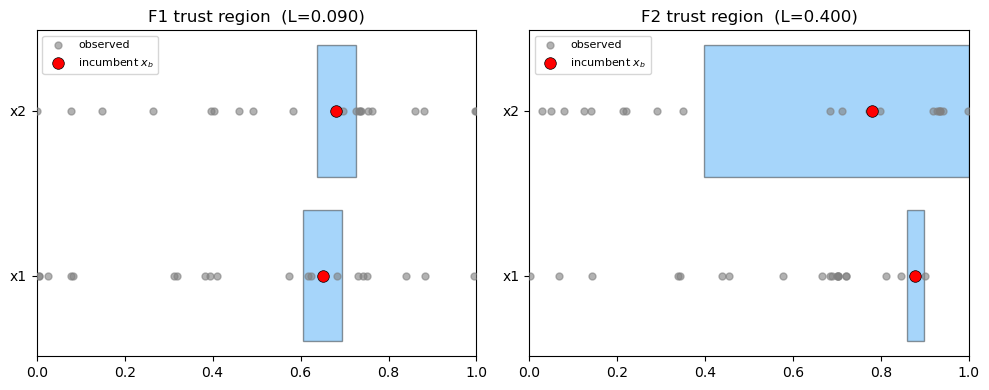

In [25]:
turbo_fns = [fn for fn in range(1,9)
             if df_best.loc[fn,'strategy'] in ('turbo','turbo_mb')]
fig, axes = plt.subplots(1, len(turbo_fns), figsize=(5*len(turbo_fns), 4))
if len(turbo_fns)==1: axes=[axes]
for ax, fn in zip(axes, turbo_fns):
    lo, hi = TURBO_STATE[fn]["lo"], TURBO_STATE[fn]["hi"]
    xb = TURBO_STATE[fn]["xb"]; nd = len(xb)
    dims = [f"x{i+1}" for i in range(nd)]
    X = all_X[fn-1].values   # all observed points for this function

    ax.barh(dims, hi-lo, left=lo, color='#2196F3', alpha=.4, edgecolor='k', zorder=1)
    for j in range(nd):
        ax.scatter(X[:, j], [dims[j]]*len(X), color='grey', s=25, alpha=.6, zorder=3,
                   label='observed' if j==0 else None)
    ax.scatter([xb[0]], [dims[0]], color='red', s=0, zorder=4)  # dummy for legend spacing
    for j in range(nd):
        ax.scatter([xb[j]], [dims[j]], color='red', s=70, zorder=5,
                   label='incumbent $x_b$' if j==0 else None, edgecolors='k', linewidths=.5)
    ax.set_xlim(0,1); ax.set_title(f'F{fn} trust region  (L={TURBO_STATE[fn]["length"]:.3f})')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Dimension importance — multi-method diagnostic
Four normalised views per dimension: **ard** (GP lengthscale), **gp_grad** (GP posterior-mean sensitivity), **rf_perm** (RF permutation importance), **shap** (SHAP on RF). Because ard≈gp_grad (r=0.98) and rf_perm≈shap (r=0.98), they collapse into two independent family scores — **gp_fam** and **rf_fam** — whose mean is the **consensus** and whose gap is **disagree**. A dim is **frozen** only when its ARD lengthscale is at the ceiling *and* both families agree it is inert; a high `disagree` flags an interaction candidate (never frozen).

In [27]:
for fn in range(1,9):
    d = diagnostics[fn]
    print(f"\nF{fn}  (LOO R^2 = {d['loo_r2']:+.3f})")
    print(d['importance'].to_string(index=False))


F1  (LOO R^2 = -0.086)
dim  ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1  1.0    0.875    1.000 1.000   0.937     1.0      0.969     0.063         0.05      False   False
 x2  1.0    1.000    0.222 0.378   1.000     0.3      0.650     0.700         0.05      False   False

F2  (LOO R^2 = +0.520)
dim   ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1 1.000    1.000    1.000  1.00   1.000   1.000      1.000     0.000         0.05      False   False
 x2 0.005    0.001    0.111  0.25   0.003   0.181      0.092     0.177         9.27      False   False

F3  (LOO R^2 = +0.319)
dim   ard  gp_grad  rf_perm  shap  gp_fam  rf_fam  consensus  disagree  lengthscale  saturated  frozen
 x1 0.005    0.000    0.045 0.135   0.003   0.090      0.046     0.087        20.00       True    True
 x2 0.117    0.097    0.151 0.323   0.107   0.237      0.172     0.130         0.85      False   False
 x3 

    ### Individual metrics per dimension (grouped bars)
The raw four scores side by side, so you can read each dimension directly rather than through the collapsed consensus. Blues = GP family (ard, gp_grad); greens = RF family (rf_perm, shap). Where the blue pair and the green pair diverge, that dimension is an interaction candidate.

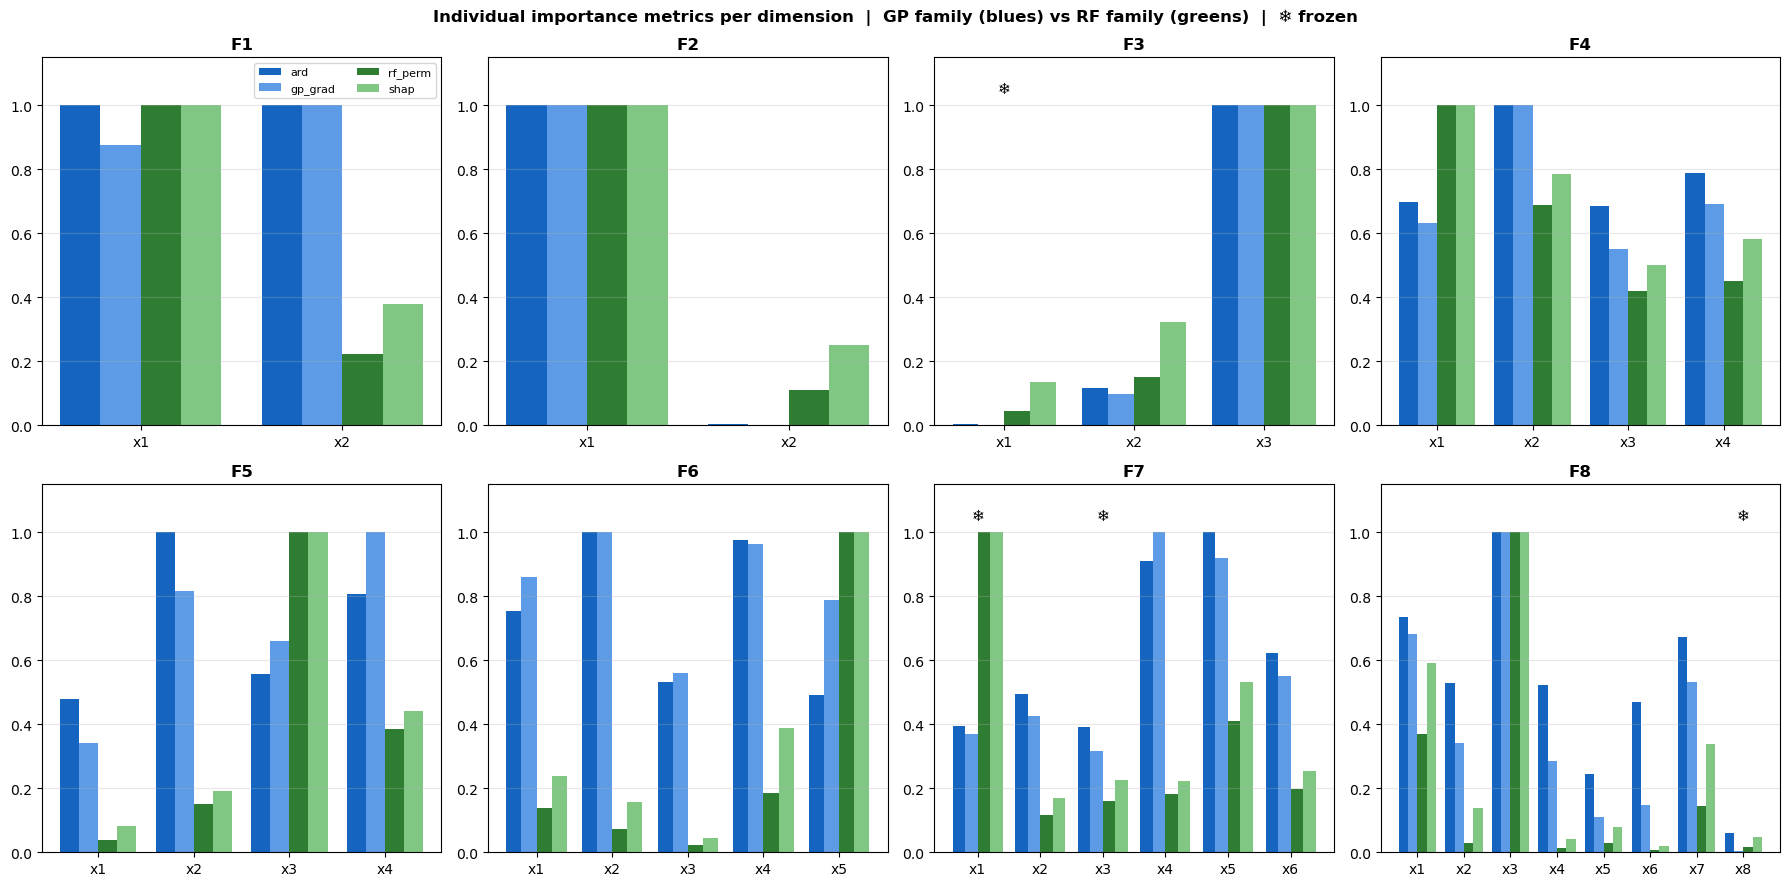

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9)); axes = axes.ravel()
metrics = ['ard','gp_grad','rf_perm','shap']
mc = {'ard':'#1565C0','gp_grad':'#5E9BE6','rf_perm':'#2E7D32','shap':'#81C784'}
for fn in range(1,9):
    ax=axes[fn-1]; imp=diagnostics[fn]['importance']; dims=imp['dim'].tolist()
    x=np.arange(len(dims)); w=0.2
    for k,m in enumerate(metrics):
        ax.bar(x+(k-1.5)*w, imp[m].values, w, label=m, color=mc[m])
    for j,fr in enumerate(imp['frozen'].values):
        if fr: ax.text(j,1.04,'❄',ha='center',fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(dims); ax.set_ylim(0,1.15)
    ax.set_title(f'F{fn}',fontweight='bold'); ax.grid(axis='y',alpha=.3)
    if fn==1: ax.legend(fontsize=8, ncol=2)
fig.suptitle('Individual importance metrics per dimension  |  GP family (blues) vs RF family (greens)  |  ❄ frozen',fontweight='bold')
plt.tight_layout(); plt.show()

### Family-aware heatmaps — GP-family · RF-family · disagreement

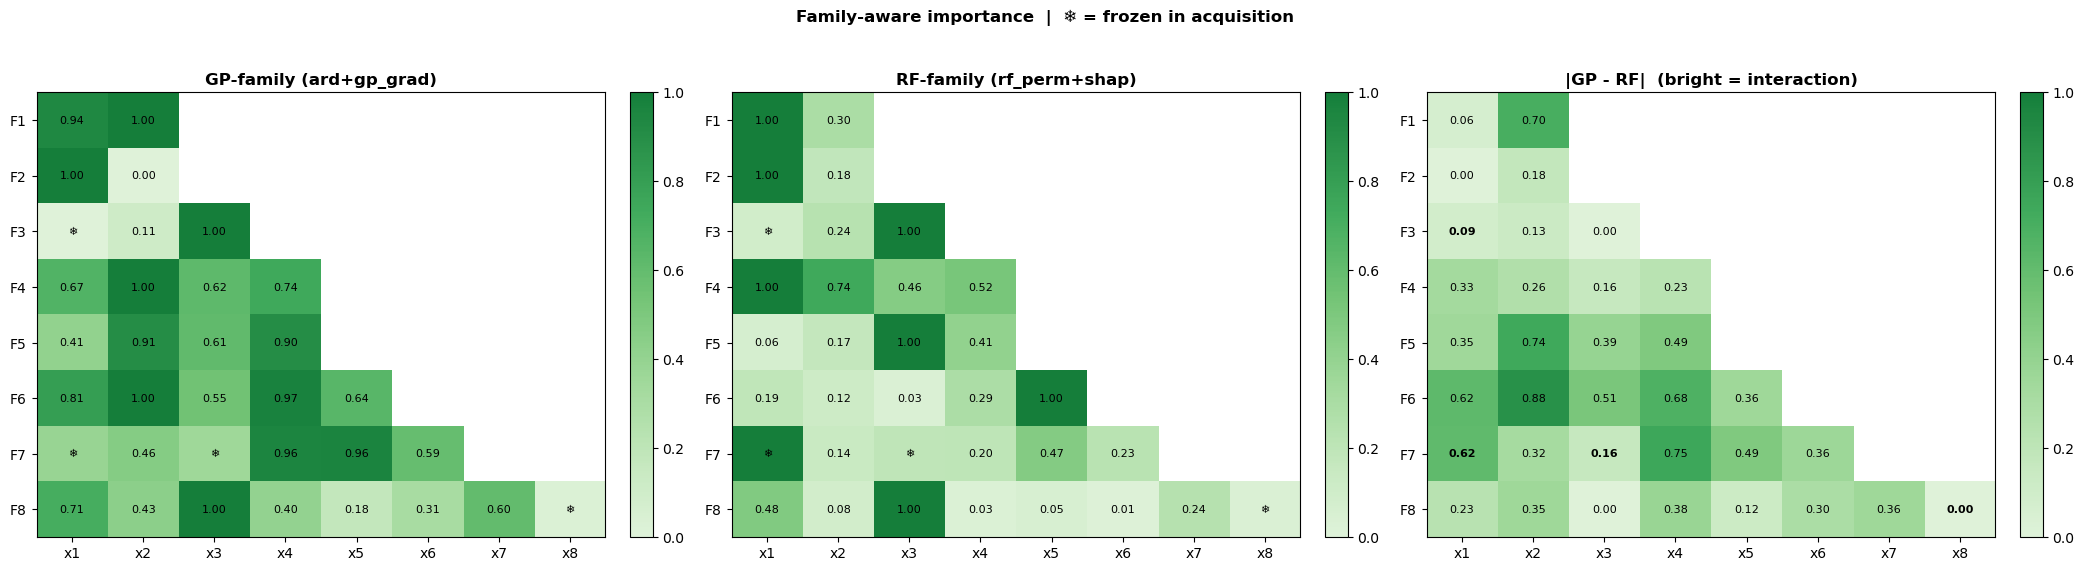

In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Clear any cached figure properties completely
plt.close('all') 
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

# 2. Re-create the light green colormap fresh
truncated_greens = mcolors.LinearSegmentedColormap.from_list(
    'light_greens', plt.cm.Greens(np.linspace(0.15, 0.8, 256))
)

# 3. Explicitly pass the custom colormap object
panels = [('gp_fam','GP-family (ard+gp_grad)', truncated_greens),
          ('rf_fam','RF-family (rf_perm+shap)', truncated_greens),
          ('disagree','|GP - RF|  (bright = interaction)', truncated_greens)]

for ax,(key,title,cmap) in zip(axes, panels):
    M=np.full((8,8),np.nan)
    for fn in range(1,9):
        imp=diagnostics[fn]['importance']; M[fn-1,:len(imp)]=imp[key].values
    
    # 4. Map the data directly to the new colormap limits
    im=ax.imshow(np.ma.masked_invalid(M), cmap=cmap, aspect='auto', vmin=0, vmax=1)
    
    for fn in range(1,9):
        imp=diagnostics[fn]['importance']
        for j in range(len(imp)):
            fr=imp['frozen'].iloc[j]
            lab=('❄' if (fr and key!='disagree') else f'{M[fn-1,j]:.2f}')
            ax.text(j,fn-1,lab,ha='center',va='center',fontsize=8,
                    color='black',
                    fontweight='bold' if fr else 'normal')
                    
    ax.set_xticks(range(8)); ax.set_xticklabels([f'x{i+1}' for i in range(8)])
    ax.set_yticks(range(8)); ax.set_yticklabels([f'F{i+1}' for i in range(8)])
    ax.set_title(title,fontweight='bold')
    
    # 5. Generate a fresh colorbar bound to the updated image object
    fig.colorbar(im, ax=ax, fraction=.046, pad=.04)

fig.suptitle('Family-aware importance  |  ❄ = frozen in acquisition', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


### GP-family vs RF-family scatter (per function)
Each point is a dimension. On the diagonal = the two model families agree. Off-diagonal (red, |diff|>0.5) = they conflict — the fingerprint of an interaction effect or structure one family misses. These dims are deliberately never frozen.

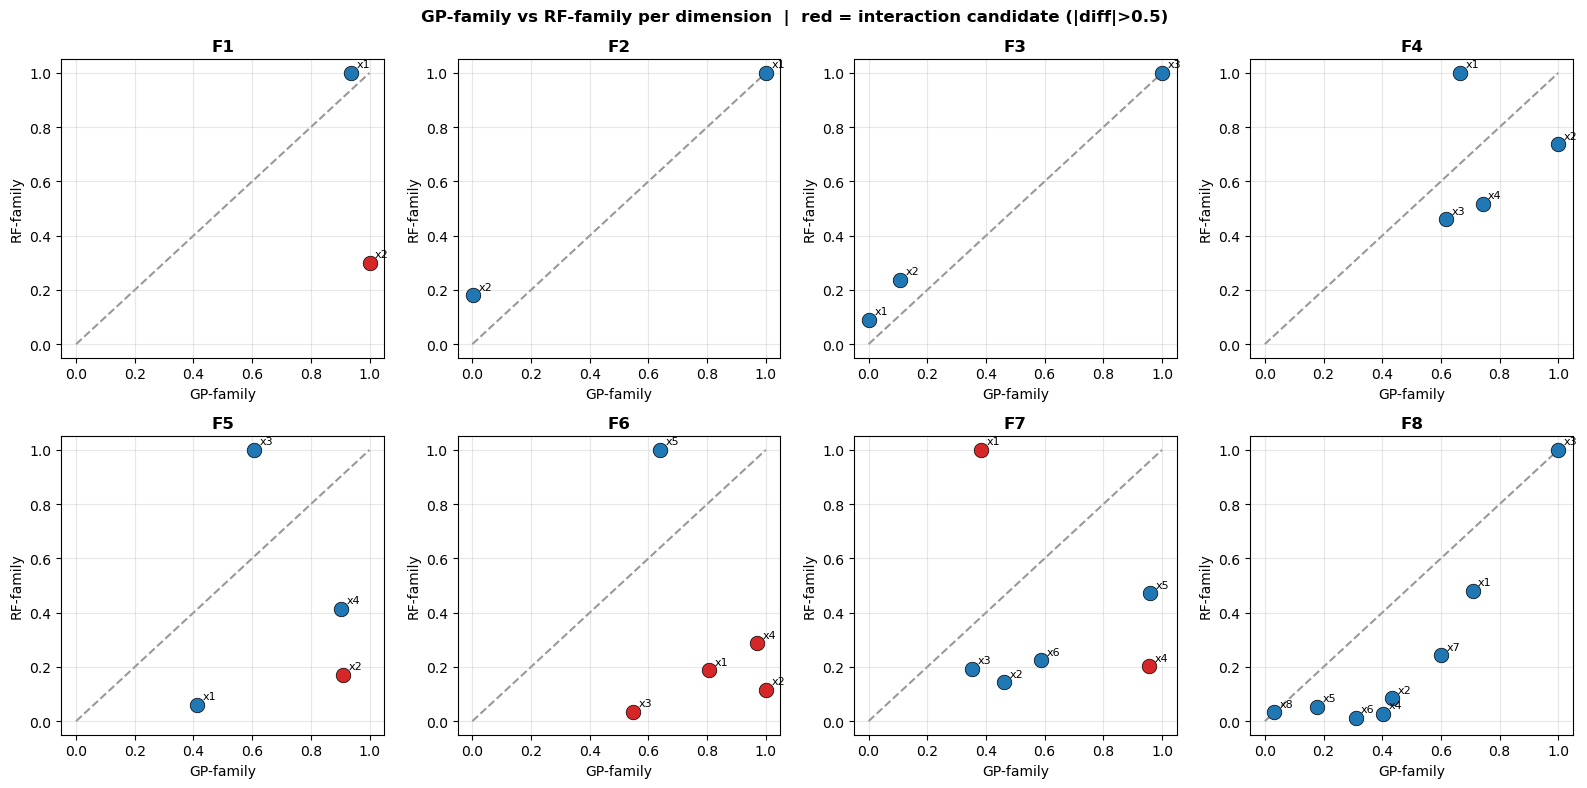

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8)); axes=axes.ravel()
for fn in range(1,9):
    ax=axes[fn-1]; imp=diagnostics[fn]['importance']
    ax.plot([0,1],[0,1],'k--',alpha=.4,zorder=1)
    for _,r in imp.iterrows():
        amb=r['disagree']>0.5
        ax.scatter(r['gp_fam'],r['rf_fam'],s=110,zorder=3,
                   c='#d62728' if amb else '#1f77b4',edgecolors='k',linewidths=.5)
        ax.annotate(r['dim'],(r['gp_fam'],r['rf_fam']),fontsize=8,
                    xytext=(4,4),textcoords='offset points')
    ax.set_xlim(-.05,1.05); ax.set_ylim(-.05,1.05)
    ax.set_xlabel('GP-family'); ax.set_ylabel('RF-family')
    ax.set_title(f'F{fn}',fontweight='bold'); ax.grid(alpha=.3)
fig.suptitle('GP-family vs RF-family per dimension  |  red = interaction candidate (|diff|>0.5)',fontweight='bold')
plt.tight_layout(); plt.show()

## Leave-one-out CV — predicted vs true (the trust gate, visualised)
Each point is one held-out observation. Tight to the dashed line = trustworthy surrogate. Red title = fails the gate (R² < 0.30) → routed to TuRBO/explore rather than global EI. Values are in the space the GP models (raw here, since no warp is active).

In [31]:
print(diagnostics[1].keys())

dict_keys(['loo_r2', 'loo_r2_before', 'loo_preds_raw', 'loo_true_raw', 'loo_diag', 'importance', 'saturation'])


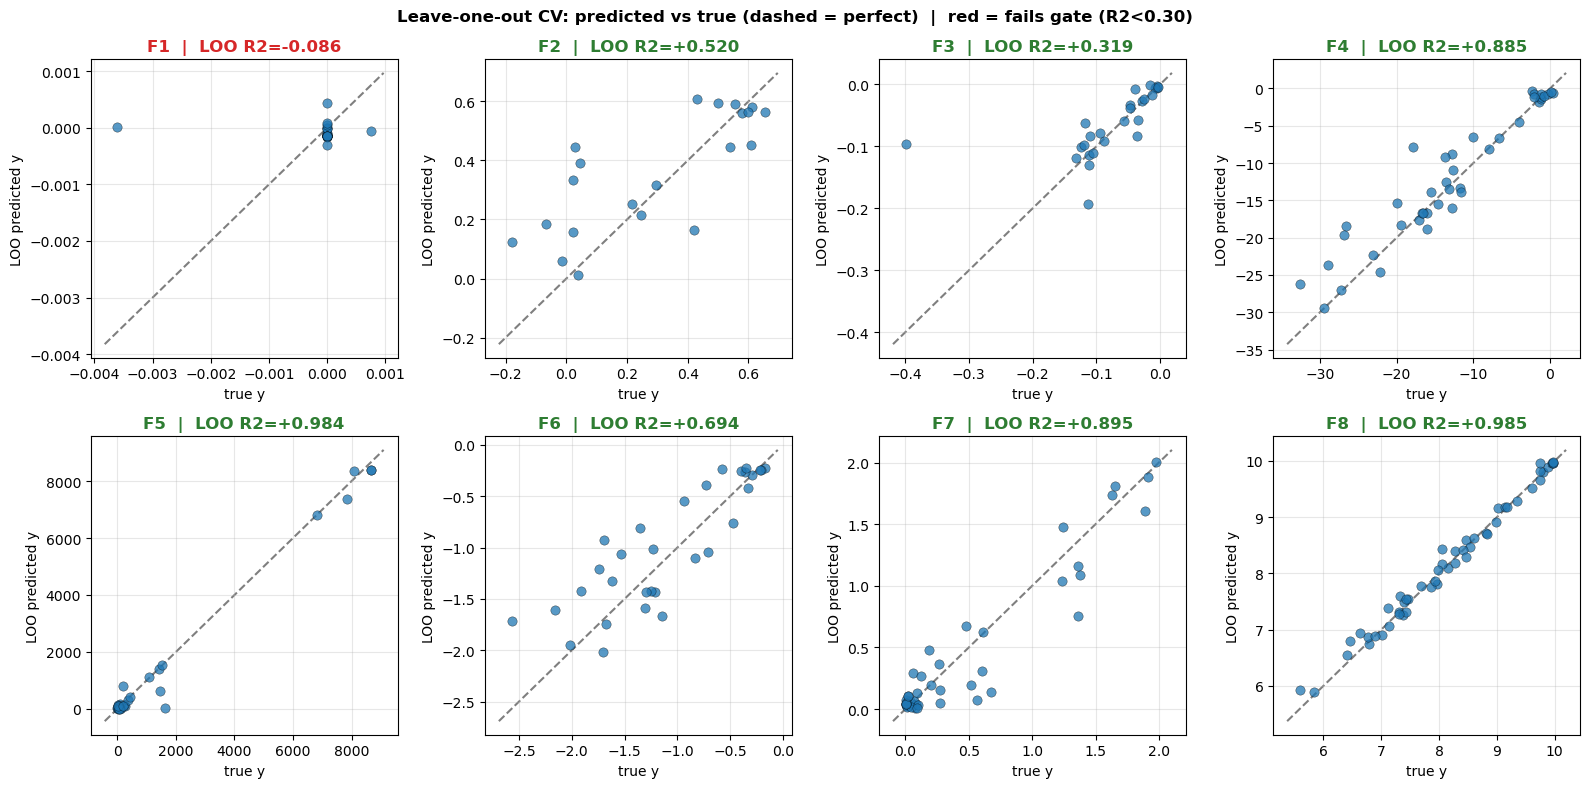

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8)); axes=axes.ravel()
for fn in range(1,9):
    ax=axes[fn-1]; d=diagnostics[fn]
    yt=np.asarray(d['loo_true_raw']); yp=np.asarray(d['loo_preds_raw'])
    lo=min(yt.min(),yp.min()); hi=max(yt.max(),yp.max()); pad=0.05*(hi-lo)+1e-9
    ax.plot([lo-pad,hi+pad],[lo-pad,hi+pad],'k--',alpha=.5,zorder=1)
    ax.scatter(yt,yp,s=45,alpha=.75,edgecolors='k',linewidths=.3,c='#1f77b4',zorder=3)
    r2=d['loo_r2']; col='#2E7D32' if r2>=.3 else '#d62728'
    ax.set_title(f'F{fn}  |  LOO R2={r2:+.3f}',fontweight='bold',color=col)
    ax.set_xlabel('true y'); ax.set_ylabel('LOO predicted y'); ax.grid(alpha=.3)
fig.suptitle('Leave-one-out CV: predicted vs true (dashed = perfect)  |  red = fails gate (R2<0.30)',fontweight='bold')
plt.tight_layout(); plt.show()

## Acquisition comparison (predicted y per acquisition)

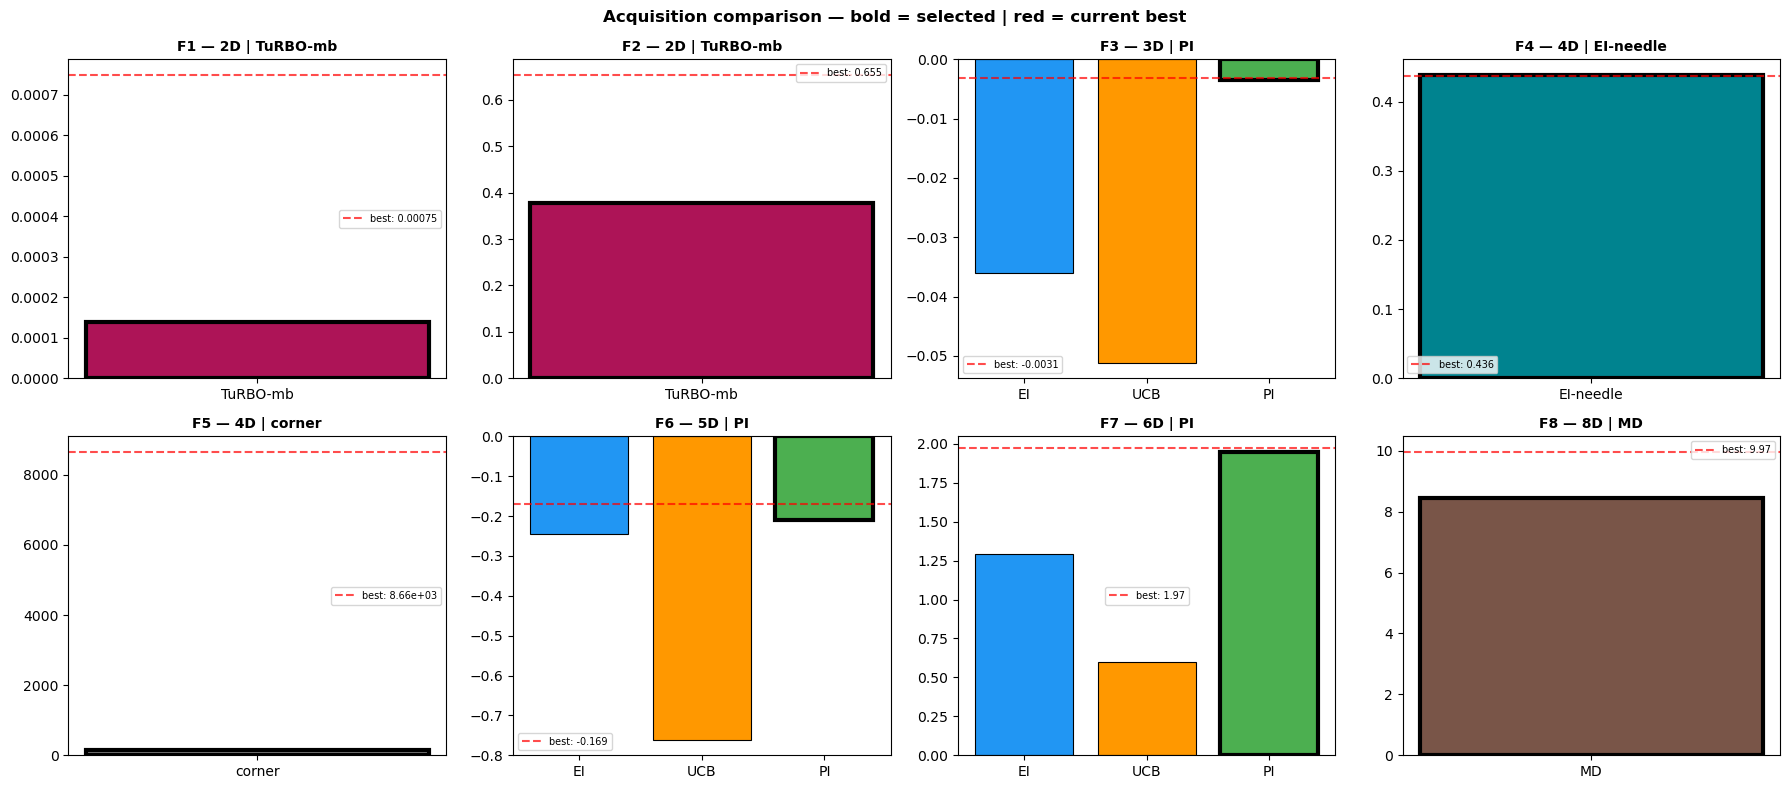

In [33]:
colours = {'EI':'#2196F3','UCB':'#FF9800','PI':'#4CAF50','TS':'#9C27B0',
           'MD':'#795548','TuRBO':'#E91E63',
           'TuRBO-mb':'#AD1457','EI-needle':'#00838F'}
fig, axes = plt.subplots(2,4,figsize=(18,8)); axes=axes.flatten()
for fn in range(1,9):
    ax=axes[fn-1]; g=df_all[df_all['function']==fn]
    winner=df_best.loc[fn,'acquisition']; yc=df_best.loc[fn,'y_max_so_far']
    names=g['acquisition'].tolist(); preds=g['predicted_y'].tolist()
    ax.bar(names, preds, color=[colours.get(a,'grey') for a in names],
           edgecolor='black', linewidth=[3 if a==winner else 0.8 for a in names])
    ax.axhline(yc, color='red', ls='--', alpha=.7, label=f'best: {yc:.3g}')
    ax.set_title(f'F{fn} — {int(g["dimensions"].iloc[0])}D | {winner}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
fig.suptitle('Acquisition comparison — bold = selected | red = current best', fontweight='bold')
plt.tight_layout(); plt.show()

## Marginal plots (x_i vs y)

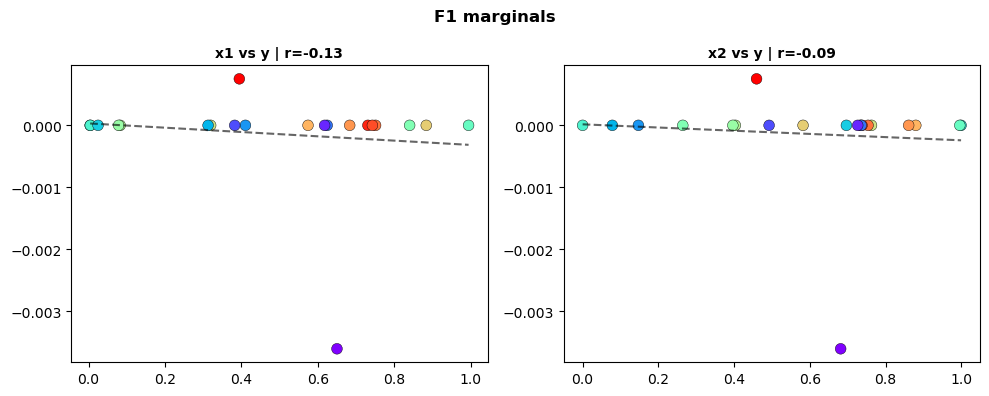

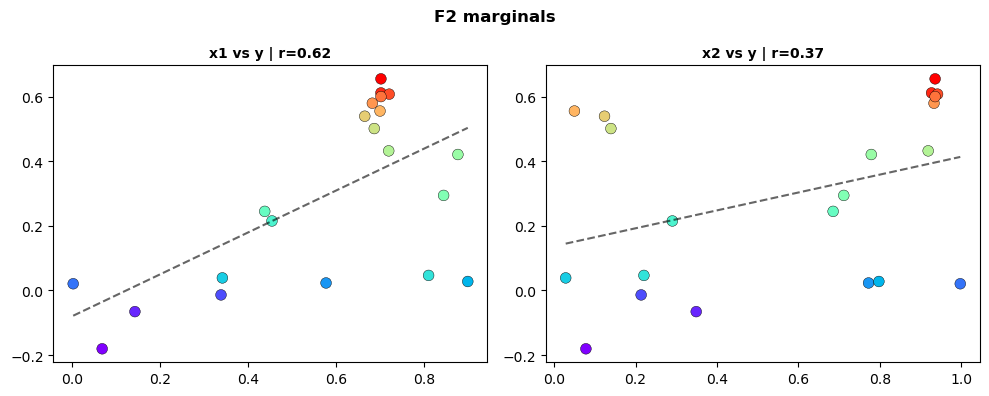

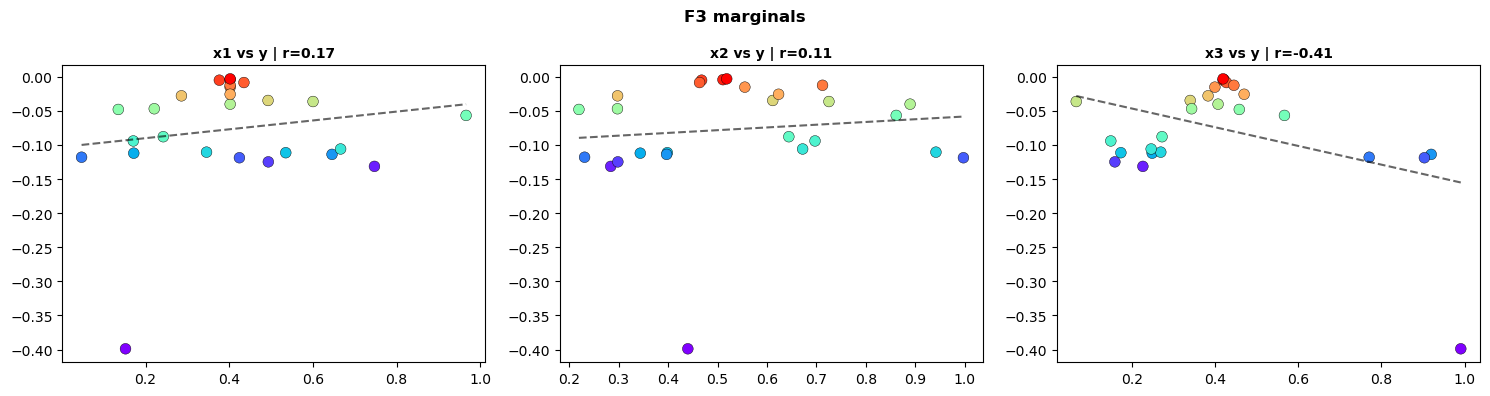

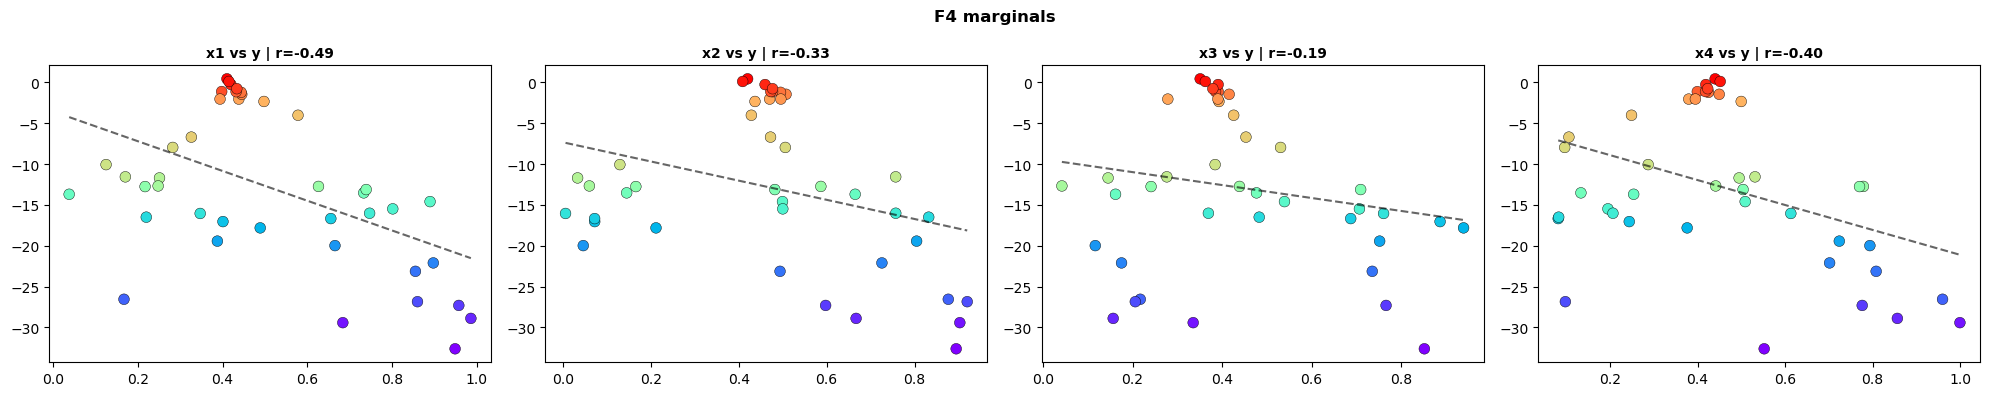

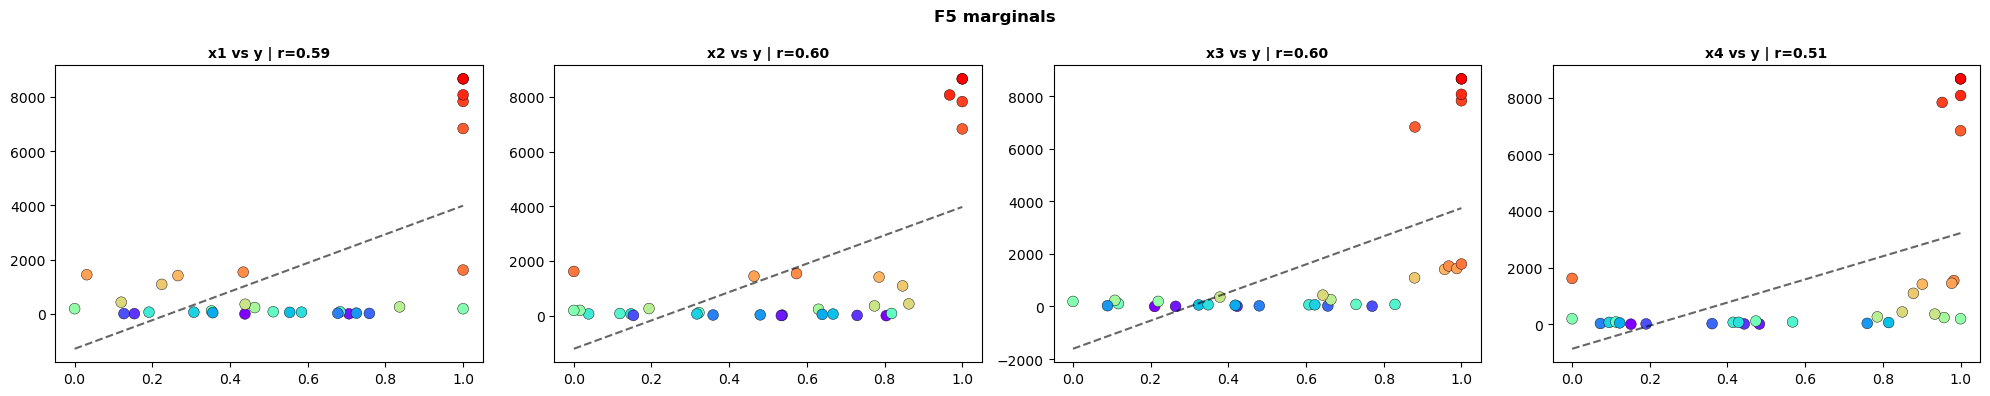

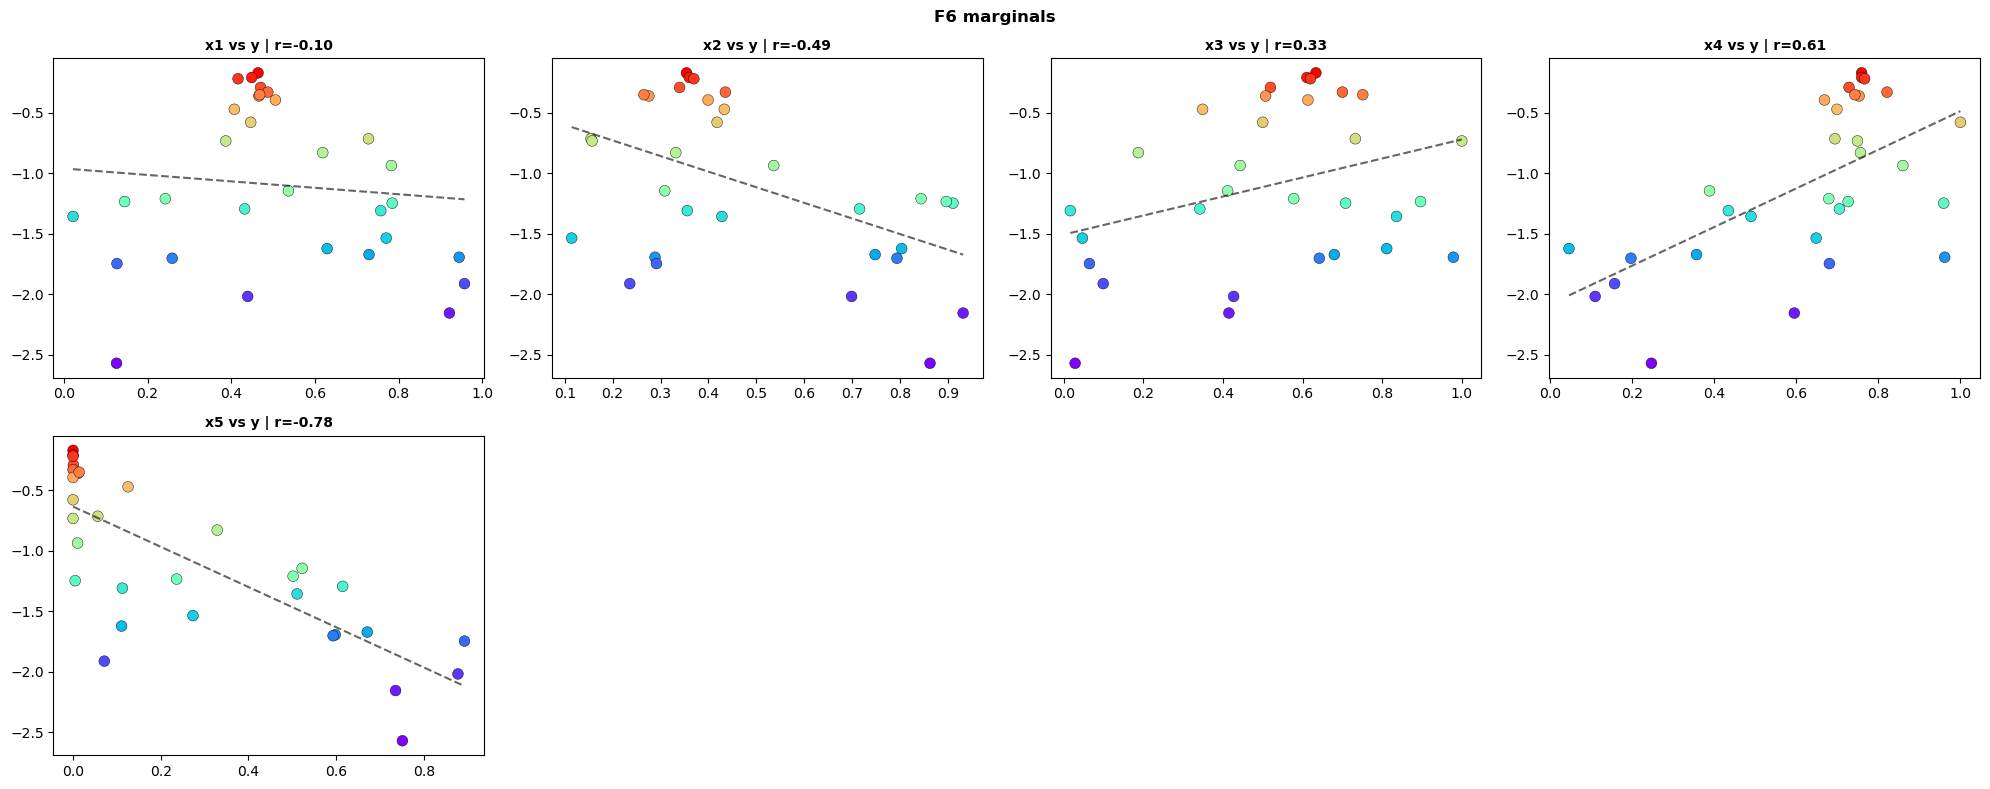

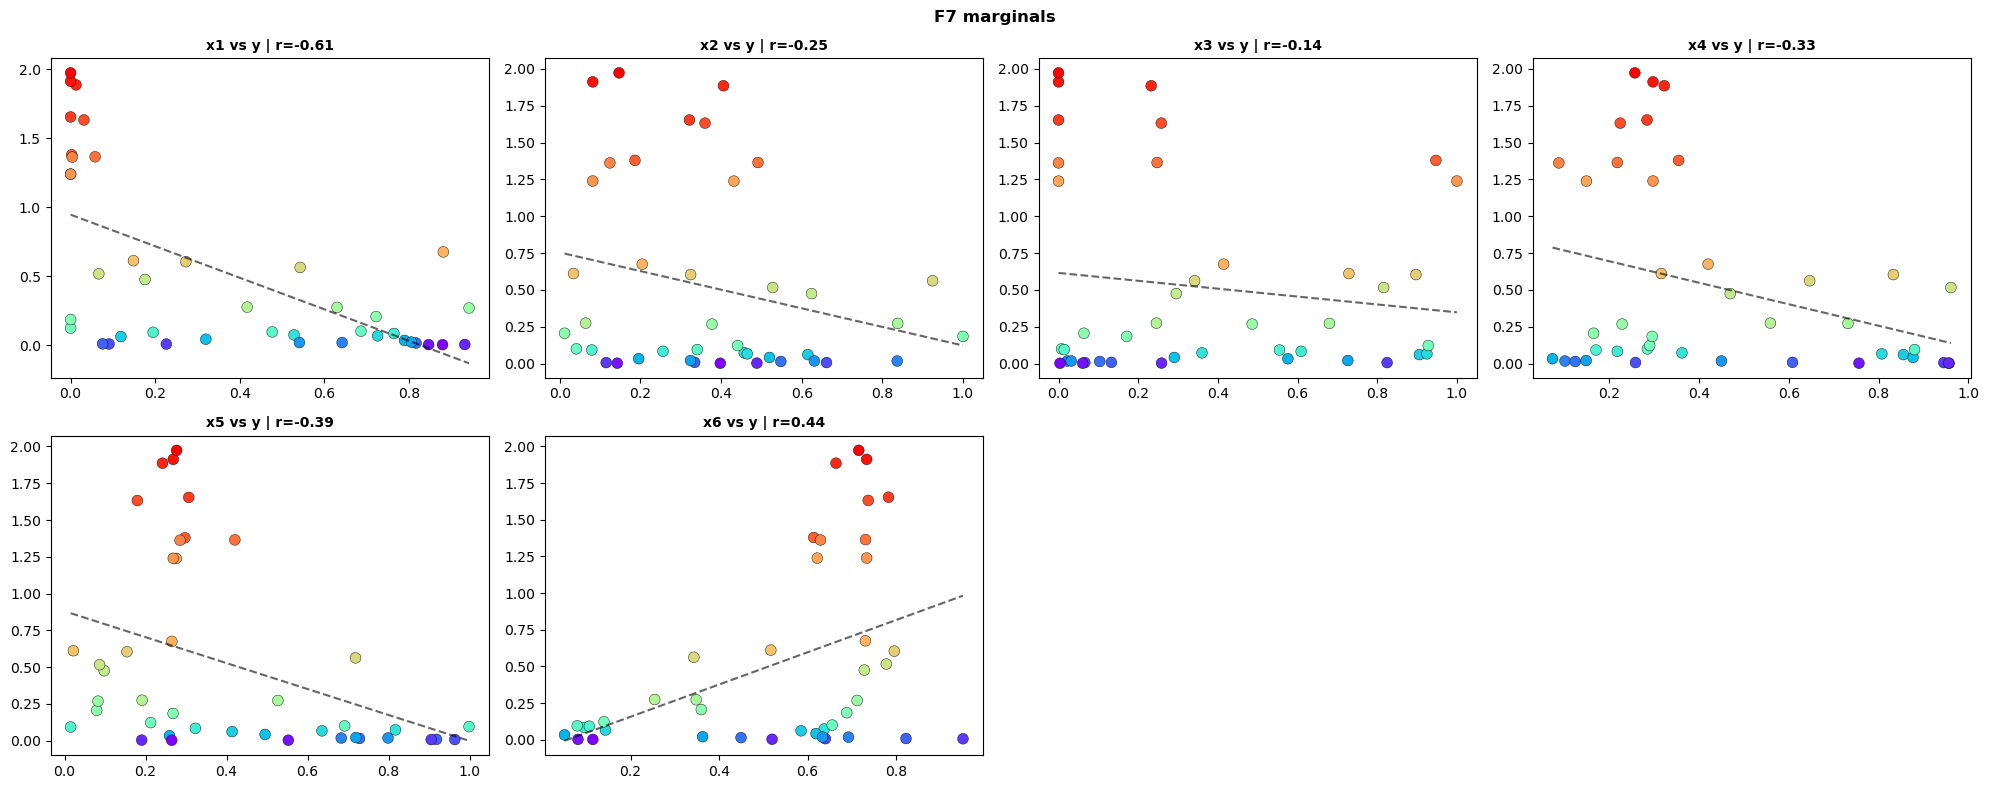

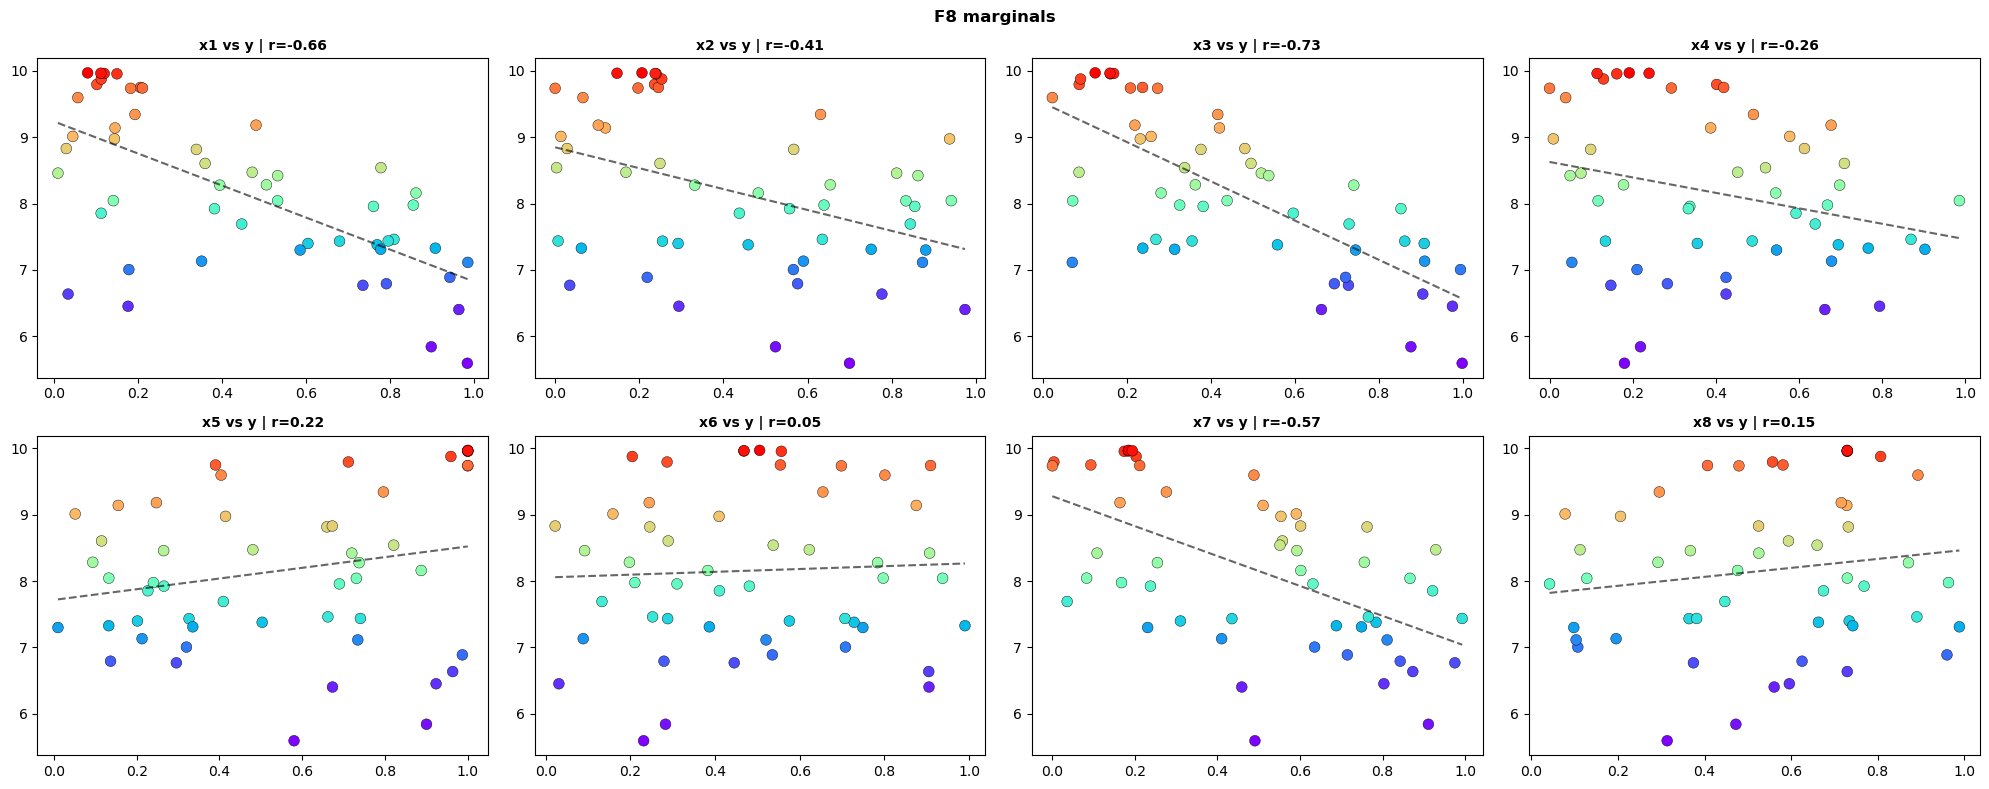

In [34]:
def plot_marginals(fn):
    X=all_X[fn-1]; y=all_y[fn-1]; nd=X.shape[1]
    nc=min(4,nd); nr=int(np.ceil(nd/nc))
    fig,axes=plt.subplots(nr,nc,figsize=(5*nc,4*nr),squeeze=False)
    yr=y.rank(pct=True)
    for i,c in enumerate(X.columns):
        ax=axes[i//nc][i%nc]
        ax.scatter(X[c], y, c=yr, cmap='rainbow', s=60, edgecolors='k', linewidths=.3)
        z=np.polyfit(X[c],y,1); xl=np.linspace(X[c].min(),X[c].max(),50)
        ax.plot(xl,np.poly1d(z)(xl),'k--',alpha=.6)
        ax.set_title(f'{c} vs y | r={X[c].corr(y):.2f}', fontsize=10, fontweight='bold')
    for k in range(nd,nr*nc): axes[k//nc][k%nc].axis('off')
    fig.suptitle(f'F{fn} marginals', fontweight='bold'); plt.tight_layout(); plt.show()
for fn in range(1,9): plot_marginals(fn)

## ARD lengthscale heatmap (WhiteKernel-aware via `matern_ls`)

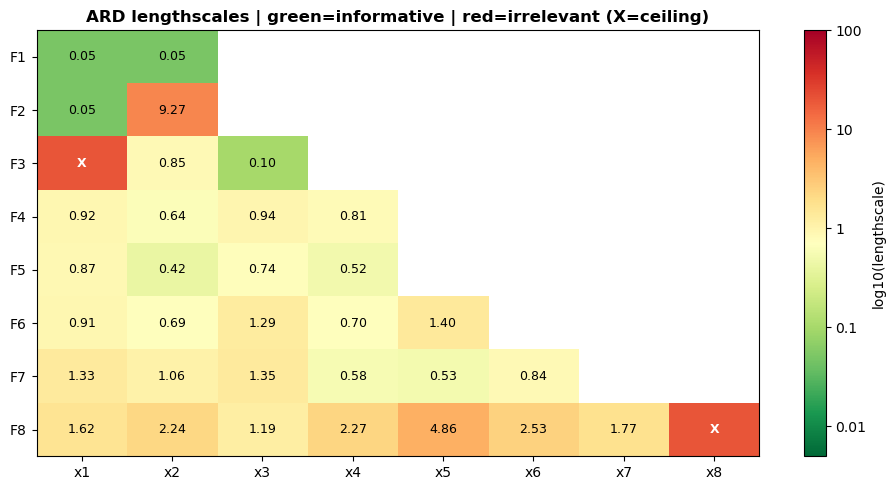

In [35]:
rows=[]
for fn in range(1,9):
    ls=matern_ls(gps[fn]); r={'function':fn}
    for c,l in zip(all_X[fn-1].columns, ls): r[c]=round(float(l),4)
    rows.append(r)
df_ls=pd.DataFrame(rows).set_index('function')
xcols=[c for c in df_ls.columns if c.startswith('x')]
data=df_ls[xcols].values.astype(float); logd=np.log10(np.where(np.isnan(data),np.nan,data))
fig,ax=plt.subplots(figsize=(max(8,len(xcols)*1.2),5))
im=ax.imshow(np.ma.masked_invalid(logd),cmap='RdYlGn_r',aspect='auto',vmin=np.log10(.005),vmax=np.log10(100))
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if not np.isnan(data[i,j]):
            v=data[i,j]; ax.text(j,i,'X' if v>=10 else f'{v:.2f}',ha='center',va='center',
                fontsize=9,color='white' if v>=10 else 'black',fontweight='bold' if v>=10 else 'normal')
ax.set_xticks(range(len(xcols))); ax.set_xticklabels(xcols)
ax.set_yticks(range(len(df_ls))); ax.set_yticklabels([f'F{f}' for f in df_ls.index])
ax.set_title('ARD lengthscales | green=informative | red=irrelevant (X=ceiling)',fontweight='bold')
cbar=fig.colorbar(im,ax=ax); cbar.set_ticks([np.log10(v) for v in [.01,.1,1,10,100]])
cbar.set_ticklabels(['0.01','0.1','1','10','100']); cbar.set_label('log10(lengthscale)')
plt.tight_layout(); plt.show()

## Smart scatter (2D/3D/4D projections, coloured by y, with x_next)

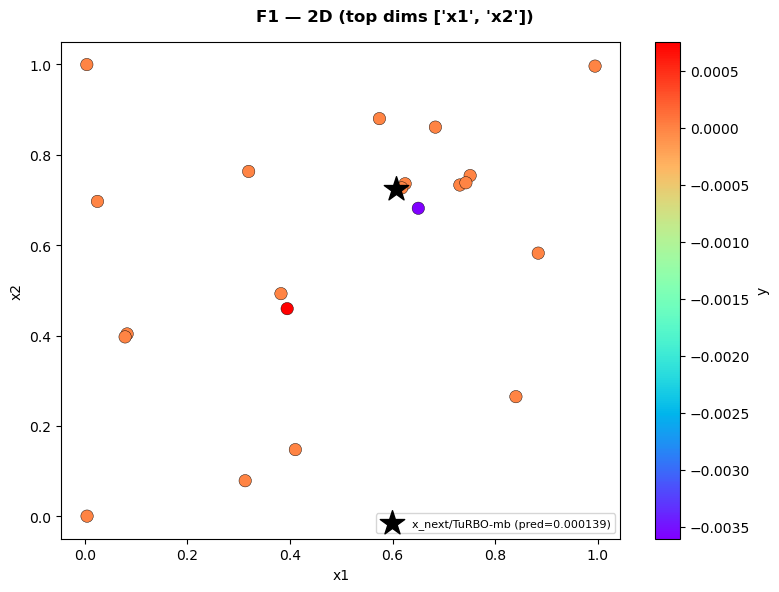

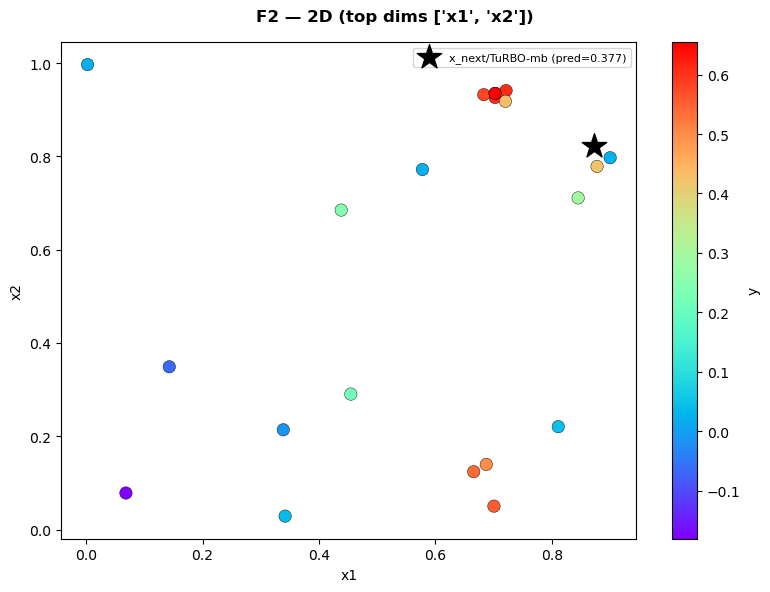

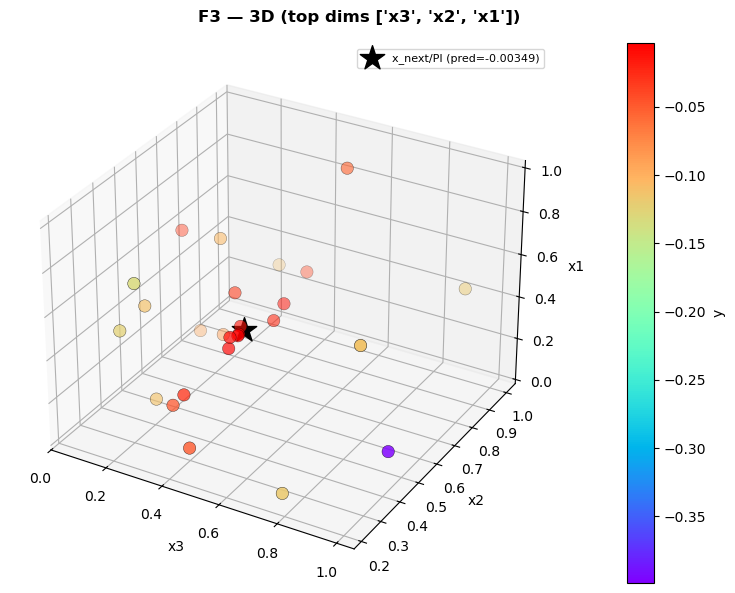

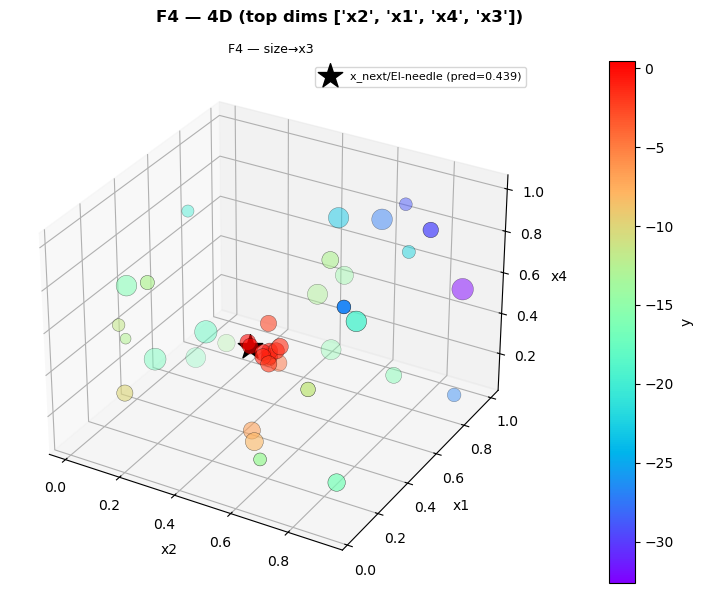

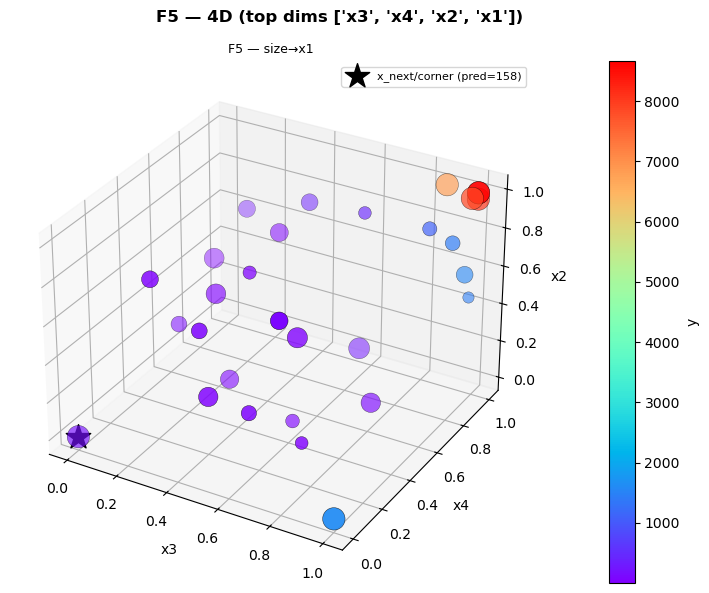

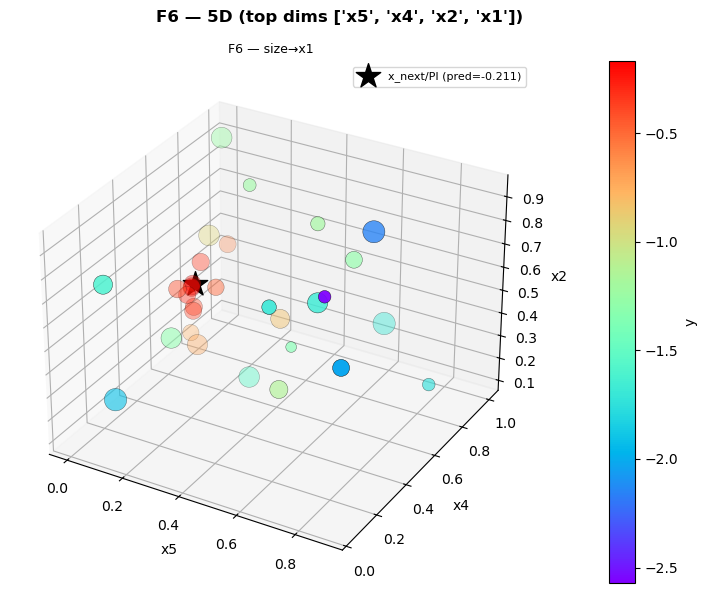

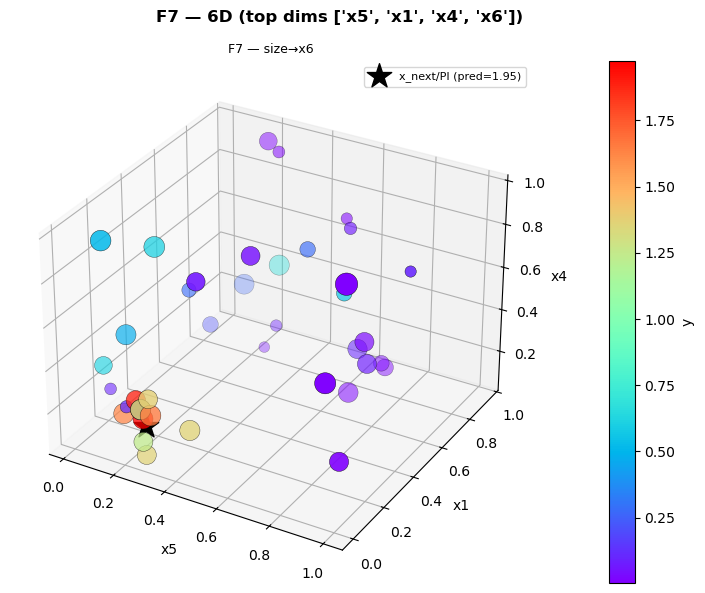

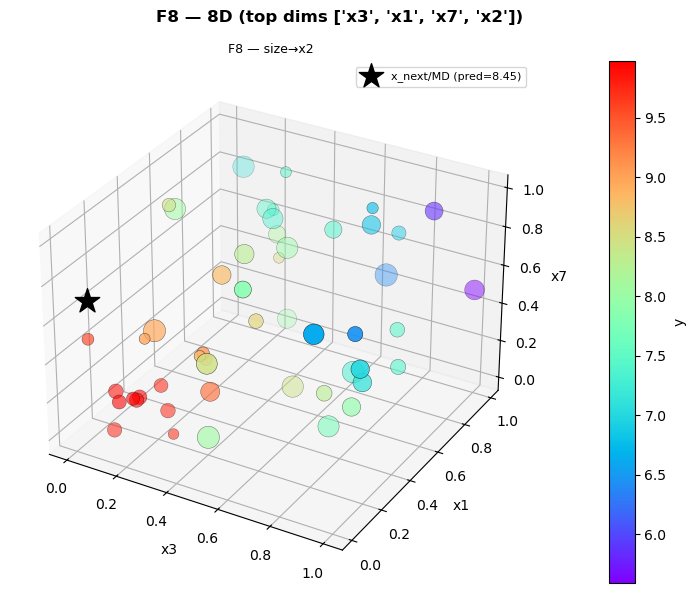

In [36]:
def plot_smart(fn):
    X=all_X[fn-1]; y=all_y[fn-1].values; nd=X.shape[1]
    dims=top_dims[fn]; pd_=dims if nd<=4 else dims[:4]; npl=len(pd_)
    norm=plt.Normalize(y.min(),y.max()); cmap=plt.cm.rainbow
    br=df_best.loc[fn]; cm_=dict(zip(X.columns.tolist(), br['x_next']))
    sc_={c:cm_[c] for c in pd_}
    lbl=f"x_next/{br['acquisition']} (pred={br['predicted_y']:.3g})"
    fig=plt.figure(figsize=(8,6))
    if npl<=2:
        d1,d2=pd_[0],pd_[1]; ax=fig.add_subplot(111)
        s=ax.scatter(X[d1],X[d2],c=y,cmap=cmap,norm=norm,s=80,edgecolors='k',linewidths=.3)
        ax.scatter(sc_[d1],sc_[d2],marker='*',s=340,color='k',zorder=6,label=lbl)
        ax.set_xlabel(d1); ax.set_ylabel(d2); fig.colorbar(s,ax=ax,label='y')
    elif npl==3:
        d1,d2,d3=pd_; ax=fig.add_subplot(111,projection='3d')
        s=ax.scatter(X[d1],X[d2],X[d3],c=y,cmap=cmap,norm=norm,s=80,edgecolors='k',linewidths=.3)
        ax.scatter(sc_[d1],sc_[d2],sc_[d3],marker='*',s=340,color='k',zorder=6,label=lbl)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3); fig.colorbar(s,ax=ax,label='y',pad=.1)
    else:
        d1,d2,d3,d4=pd_; ax=fig.add_subplot(111,projection='3d')
        sz=60+200*(X[d4]-X[d4].min())/(X[d4].max()-X[d4].min()+1e-9)
        s=ax.scatter(X[d1],X[d2],X[d3],c=y,cmap=cmap,norm=norm,s=sz,edgecolors='k',linewidths=.3)
        ax.scatter(sc_[d1],sc_[d2],sc_[d3],marker='*',s=340,color='k',zorder=6,label=lbl)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3)
        ax.set_title(f'F{fn} — size→{d4}',fontsize=9); fig.colorbar(s,ax=ax,label='y',pad=.1)
    ax.legend(fontsize=8); fig.suptitle(f'F{fn} — {nd}D (top dims {pd_})',fontweight='bold')
    plt.tight_layout(); plt.show()
for fn in range(1,9): plot_smart(fn)

## Parallel coordinates (observations + x_next)

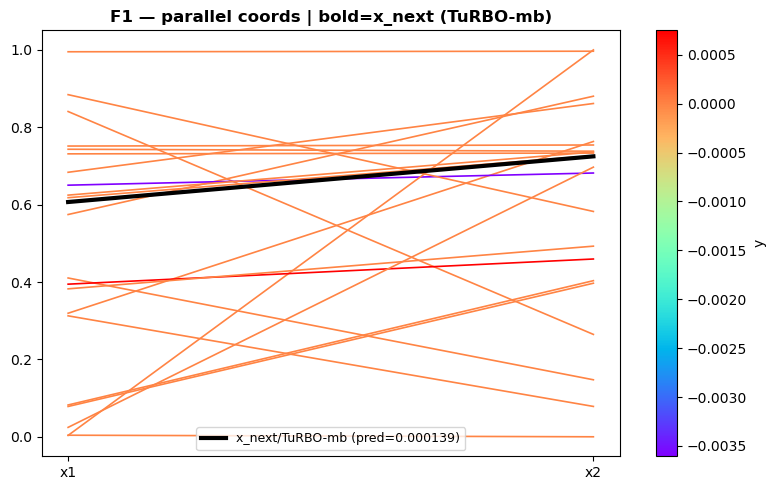

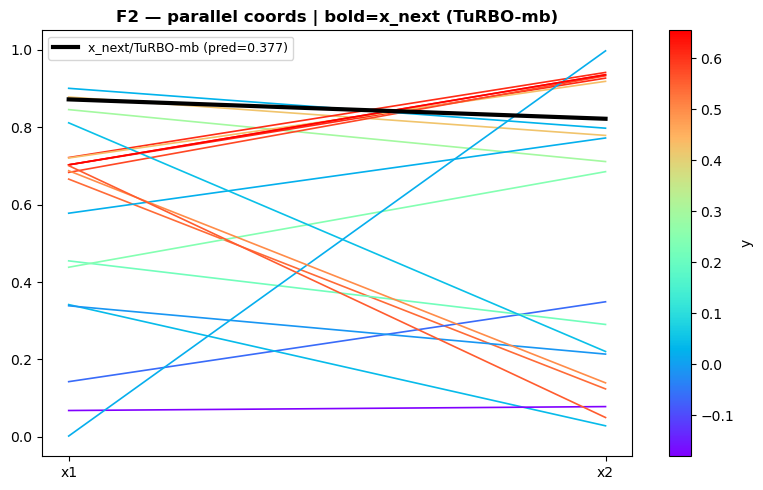

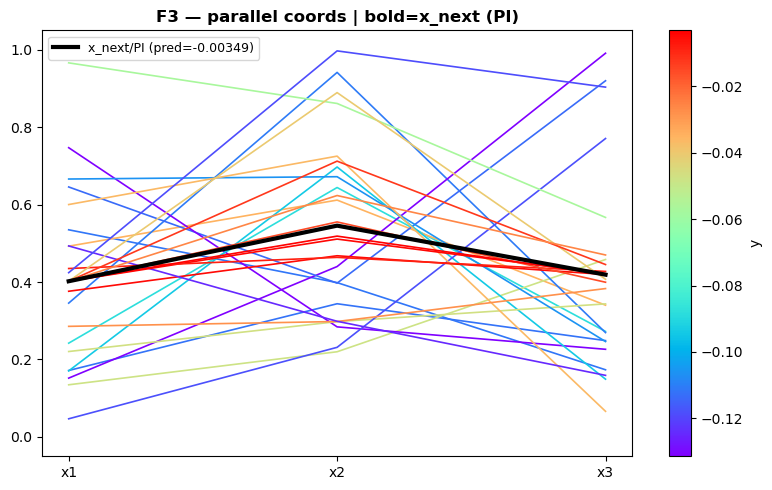

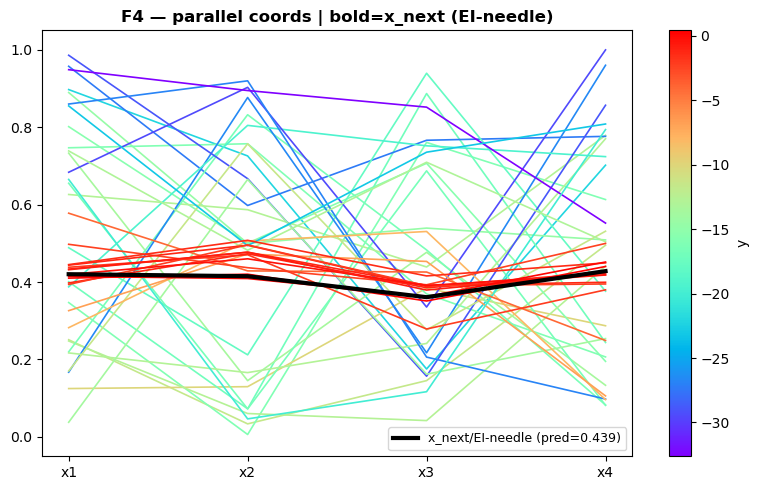

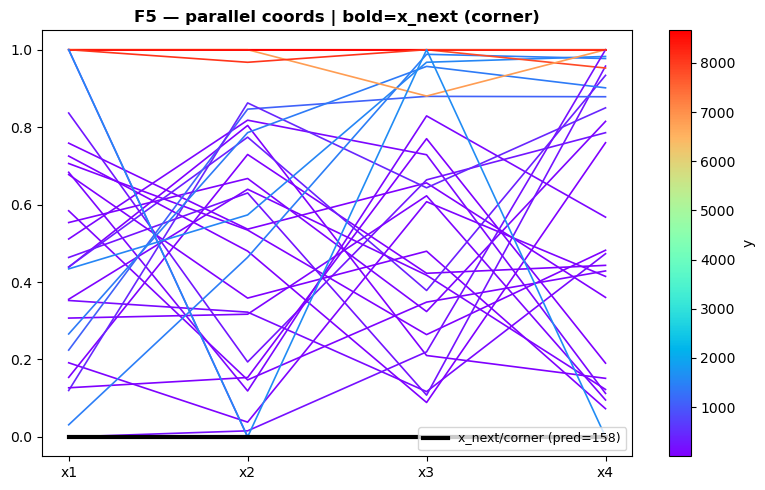

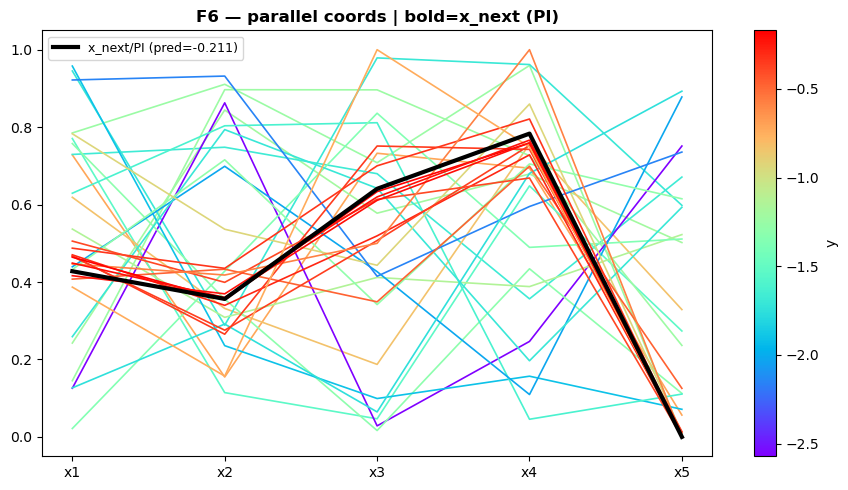

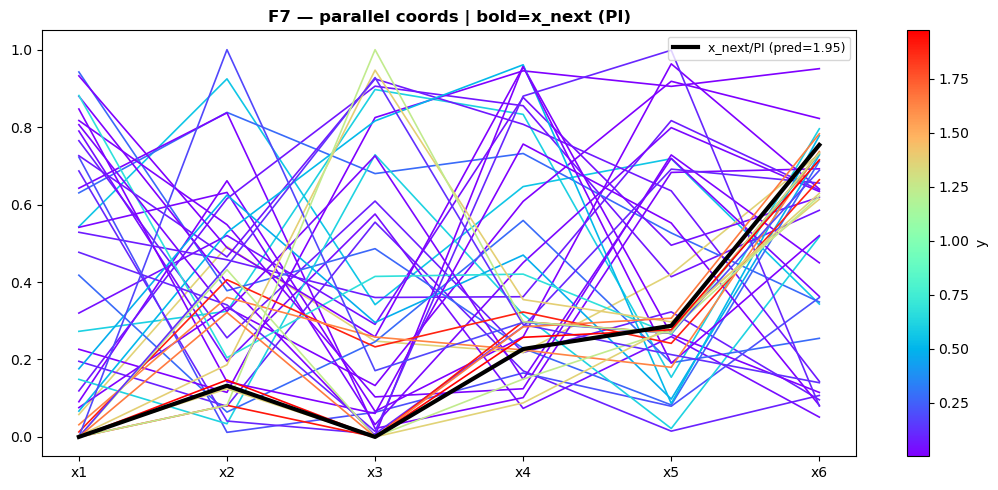

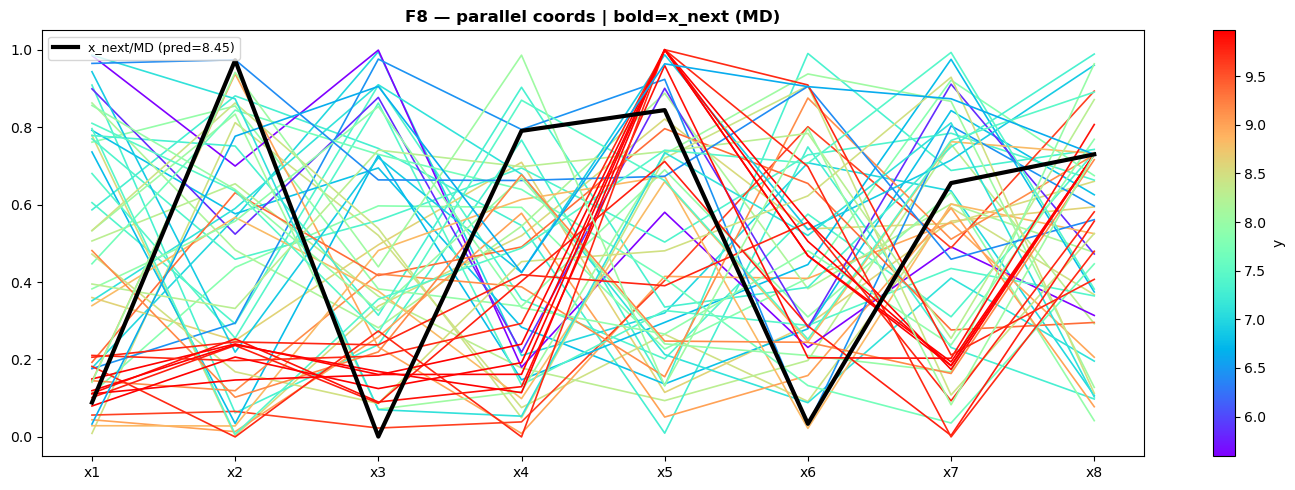

In [37]:
def plot_parallel(fn, clip_bottom=False):
    X=all_X[fn-1]; y=all_y[fn-1].values; dims=X.columns.tolist(); nd=len(dims)
    yfn = np.delete(y,np.argmin(y)) if (clip_bottom and len(y)>1) else y
    norm=mcolors.Normalize(yfn.min(),yfn.max()); cmap=cm.rainbow
    br=df_best.iloc[fn-1]; xn=np.array([float(v) for v in br['submission'].split('-')])
    fig,ax=plt.subplots(figsize=(max(8,nd*1.8),5)); xp=np.arange(nd)
    for i in range(len(X)):
        ax.plot(xp, X.iloc[i].values, color=cmap(norm(np.clip(y[i],yfn.min(),yfn.max()))), lw=1.2)
    ax.plot(xp, xn, 'k-', lw=3, zorder=5, label=f"x_next/{br['acquisition']} (pred={br['predicted_y']:.3g})")
    ax.set_xticks(xp); ax.set_xticklabels(dims); ax.set_ylim(-.05,1.05); ax.legend(fontsize=9)
    sm=cm.ScalarMappable(cmap=cmap,norm=norm); sm.set_array([]); fig.colorbar(sm,ax=ax,label='y')
    ax.set_title(f'F{fn} — parallel coords | bold=x_next ({br["acquisition"]})',fontweight='bold')
    plt.tight_layout(); plt.show()
for fn in range(1,9): plot_parallel(fn, clip_bottom=(fn==3))

## Progress tracking

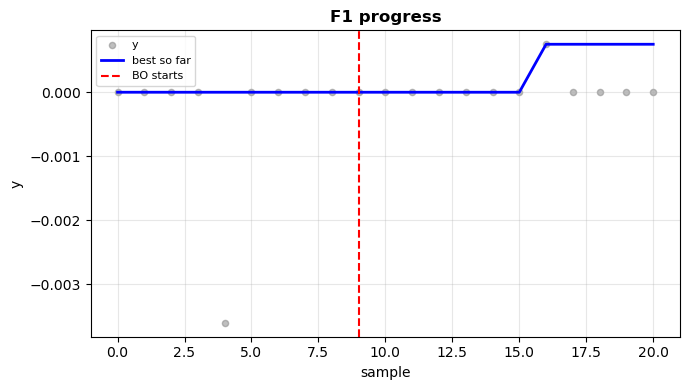

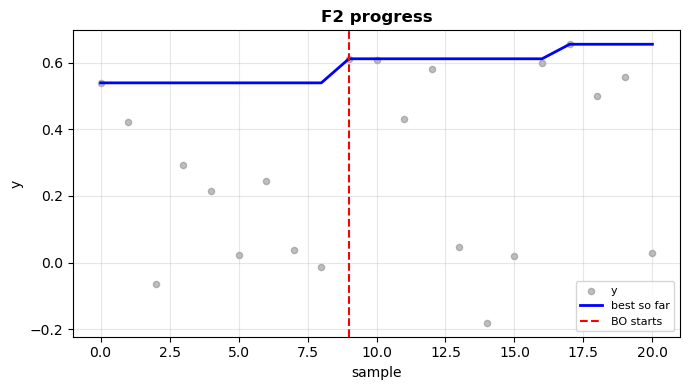

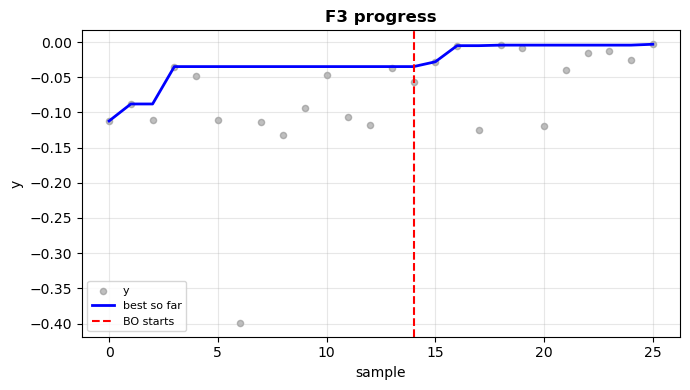

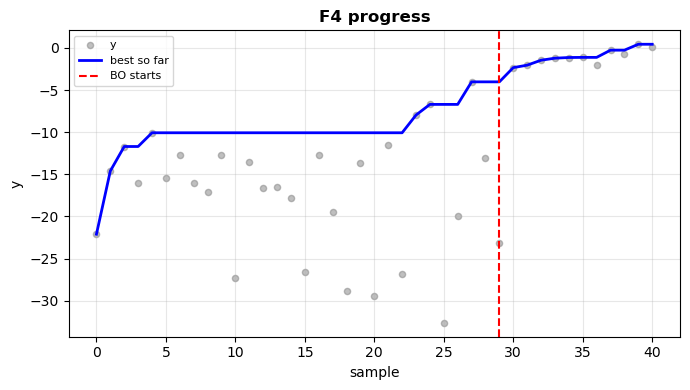

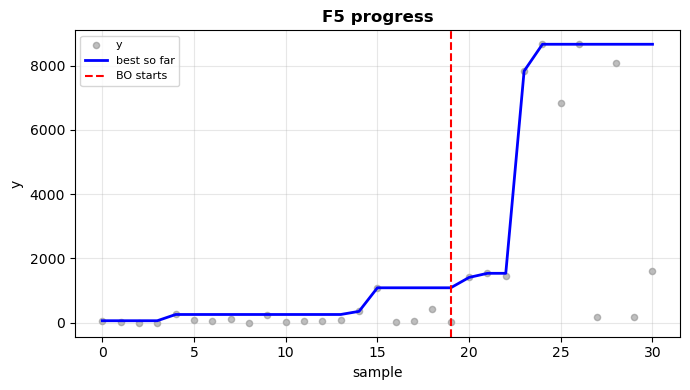

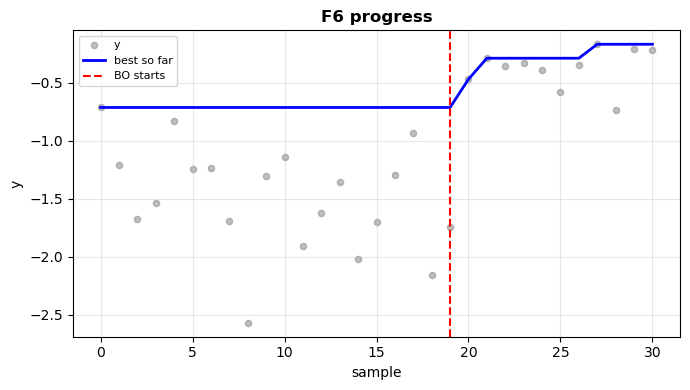

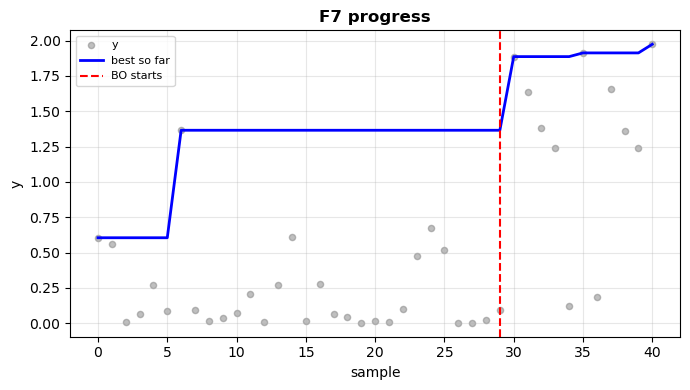

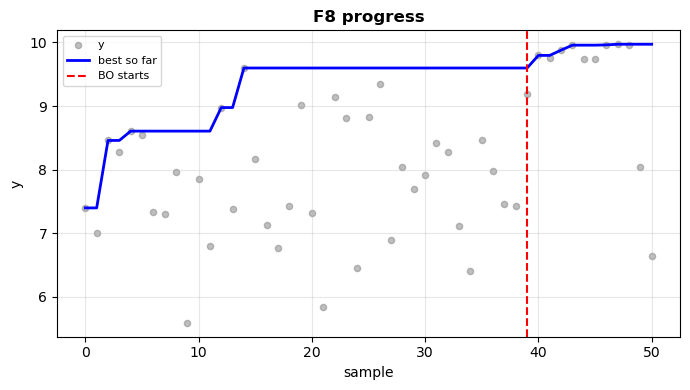

Function           Best y    At idx
F1                 0.0008        16
F2                 0.6548        17
F3                -0.0031        25
F4                 0.4364        39
F5              8662.4050        24
F6                -0.1692        27
F7                 1.9734        40
F8                 9.9720        47


In [38]:
def plot_progress(fn):
    y=all_y[fn-1].values; ni=[10,10,15,30,20,20,30,40][fn-1]
    rm=np.maximum.accumulate(y); it=np.arange(len(y))
    fig,ax=plt.subplots(figsize=(7,4))
    ax.scatter(it,y,color='grey',s=20,alpha=.5,label='y')
    ax.plot(it,rm,color='blue',lw=2,label='best so far')
    ax.axvline(ni-1,color='red',ls='--',lw=1.5,label='BO starts')
    ax.set_xlabel('sample'); ax.set_ylabel('y'); ax.set_title(f'F{fn} progress',fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
for fn in range(1,9): plot_progress(fn)
print(f"{'Function':<10}{'Best y':>15}{'At idx':>10}")
for fn in range(1,9):
    y=all_y[fn-1].values; print(f"F{fn:<9}{y.max():>15.4f}{int(np.argmax(y)):>10}")

## Acquisition alignment across dimensions

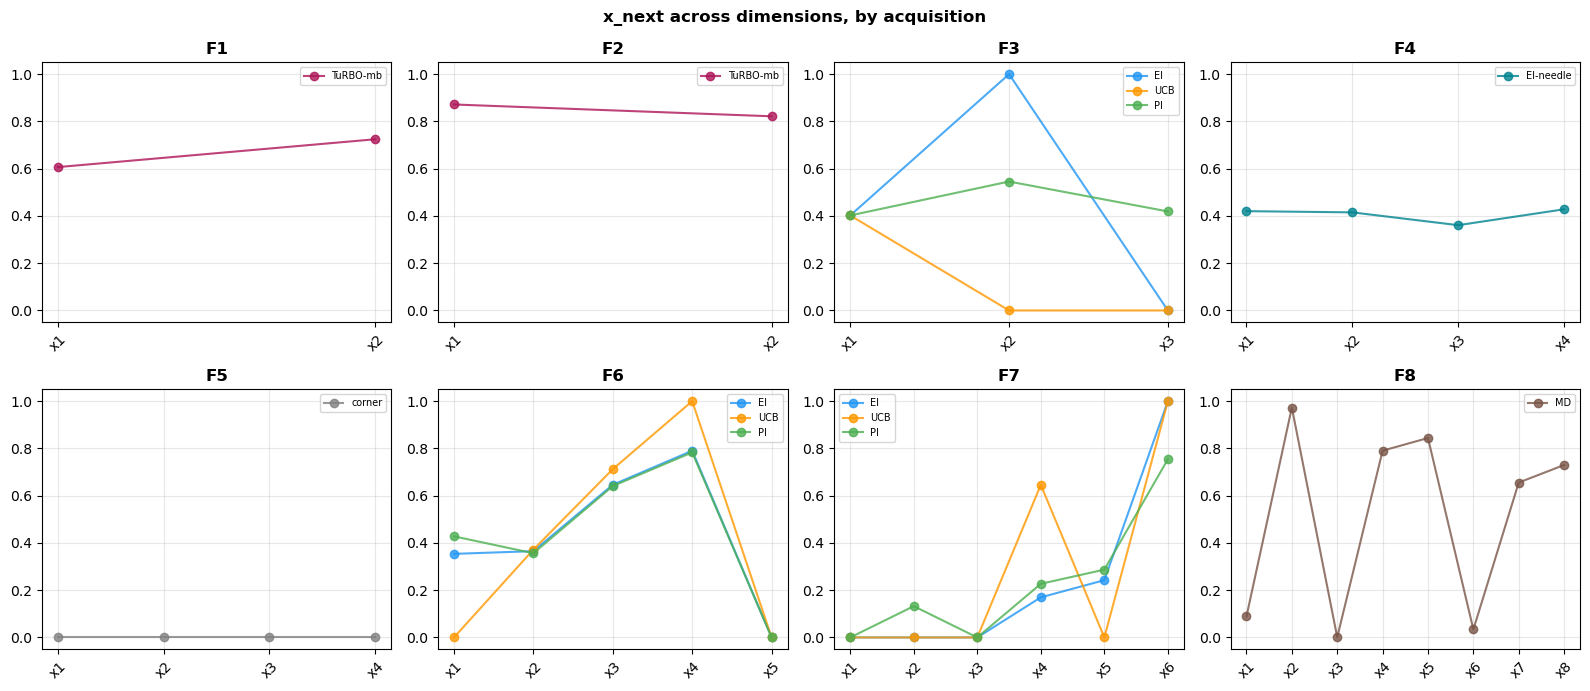

In [39]:
fig,axes=plt.subplots(2,4,figsize=(16,7)); axes=axes.ravel()
cols_all=[f'x{i}_suggested' for i in range(1,9)]
for fn in range(1,9):
    ax=axes[fn-1]; g=df_all[df_all['function']==fn]; nd=int(g['dimensions'].iloc[0])
    cs=cols_all[:nd]
    for _,r in g.iterrows():
        ax.plot(range(nd), r[cs].astype(float).values, 'o-',
                label=r['acquisition'], color=colours.get(r['acquisition'],'grey'), alpha=.8)
    ax.set_xticks(range(nd)); ax.set_xticklabels([c.replace('_suggested','') for c in cs], rotation=45)
    ax.set_ylim(-.05,1.05); ax.set_title(f'F{fn}',fontweight='bold'); ax.grid(alpha=.3); ax.legend(fontsize=7)
fig.suptitle('x_next across dimensions, by acquisition', fontweight='bold'); plt.tight_layout(); plt.show()